<div align="center">

# Ford Vision — IA & Machine Learning
## Segmentação e Scoring de Clientes para Retenção no Pós-Venda

---

### Identificação do Grupo

| Campo | Informação |
|---|---|
| **Projeto** | Ford Vision |
| **Desafio** | Desafio 02 — Impulsionando o VIN Share na América do Sul |
| **Disciplina** | Inteligência Artificial & Machine Learning |
| **Turma** | 3ESS |
| **Instituição** | FIAP — Faculdade de Informática e Administração Paulista |
| **Parceiro** | Ford Motor Company |
| **Sprint** | Sprint 3 — 2º Semestre / 2026 |

### Integrantes

| Nome | RM |
|---|---|
| Ricardo Di Tilia | RM555155 |
| Bento Rangel | RM559124 |
| Eric Yuji | RM554869 |
| Kaue Pires | RM554403 |
| Higor Batista | RM558907 |

</div>

---

### Objetivo

Desenvolver uma solução de IA/ML que permita à Ford e às suas concessionárias **pontuar a base ativa de veículos** e identificar o perfil provável de cada cliente em relação ao pós-venda (fiel, esquecido ou em abandono), alimentando **leads proativos de retenção** por concessionária.

### Enquadramento do problema (decisão de projeto)

O modelo supervisionado é um **scoring da base ativa**: ele recebe dados cadastrais do veículo/venda (modelo, ano-modelo, prazos de entrega e garantia, tempo de garantia decorrido) e estima o perfil de pós-venda **sem precisar do histórico de visitas**. Isso é útil para priorizar contatos, mas **não é uma previsão "no Dia Zero" da venda** — a seção 9.7 quantifica essa diferença (análise de sensibilidade) e a seção 10 discute as limitações.

### Mapa da Sprint 3 (rubrica de IA & ML)

| Etapa da Sprint | Peso | Onde está neste notebook |
|---|---|---|
| 1. Compreensão do problema | 1,5 | Seções 1–3 e 8.1 |
| 2. Preparação dos dados | 2,0 | Seções 4, 5.0, 8 e 9.1 |
| 3. Desenvolvimento dos modelos | 3,0 | Seção 5 (não supervisionado) e 9.2–9.4 |
| 4. Avaliação e comparação | 2,0 | Seções 9.5–9.9 |
| 5. Conclusão | 1,5 | Seções 10 e 11 (inclui deploy) |

### Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 1–2 | Bibliotecas e carregamento dos dados |
| 3 | Análise exploratória (EDA) e checagem de qualidade |
| 4 | Pré-processamento e agregação por veículo (Base 1) |
| 5 | Segmentação comportamental (K-Means) |
| 6–7 | Perfis de negócio e estratégias de retenção |
| 8 | Base 2 — definição do problema supervisionado e features |
| 9 | Modelagem: baselines, comparação, ajuste de hiperparâmetros, avaliação |
| 10 | Conclusão, limitações e trabalhos futuros |
| 11 | Deploy: artefatos, API e geração de leads |
| 12 | Exportação |

## 1. Bibliotecas e Configurações

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

import sklearn, joblib
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (silhouette_score, davies_bouldin_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             f1_score, roc_auc_score)

RANDOM_STATE = 42

# Caminhos (funciona rodando da raiz do repositório ou de /notebooks)
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
FIG_DIR   = ROOT / 'assets' / 'figures'
DATA_RAW  = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
for d in (FIG_DIR, DATA_PROC, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT))          # para importar src/features.py

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_r")

print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"Raiz do projeto: {ROOT}")

scikit-learn 1.9.1 | pandas 3.0.6 | numpy 2.5.3
Raiz do projeto: C:\Users\bento\Downloads\ford-vision-sprint3


## 2. Carregamento dos Dados

O dataset contém registros de serviços de manutenção realizados na **rede oficial Ford no Brasil** (dados reais fornecidos no desafio, sem sintéticos).
Cada linha representa **uma visita de serviço** de um veículo (identificado pelo `VIN_Hash`).

> ⚠️ Os dados brutos da Ford **não são versionados** (`data/` está no `.gitignore`). Coloque o arquivo `vin_share_Desafio_02.csv` em `data/raw/` para executar o notebook.

In [2]:
candidatos = [DATA_RAW / "vin_share_Desafio_02.csv", ROOT / "vin_share_Desafio_02.csv"]
CAMINHO_BASE = next((p for p in candidatos if p.exists()), None)
if CAMINHO_BASE is None:
    raise FileNotFoundError("Coloque vin_share_Desafio_02.csv em data/raw/ (arquivo não versionado).")

df_raw = pd.read_csv(CAMINHO_BASE, encoding='utf-8-sig', sep=';', low_memory=False)

# Conversão antecipada de datas
date_cols = ['ServiceDate', 'SalesDate', 'DeliveryDate', 'WarrantyStartDate', 'InvoiceDate', 'RegistrationDate']
for col in date_cols:
    df_raw[col] = pd.to_datetime(df_raw[col], format='mixed', errors='coerce')

DATA_REF = df_raw['ServiceDate'].max()

print(f"Shape: {df_raw.shape}")
print(f"Período: {df_raw['ServiceDate'].min().date()} → {DATA_REF.date()}")
print(f"VINs únicos: {df_raw['VIN_Hash'].nunique():,}")
print(f"Modelos ({df_raw['ModelName'].nunique()}): {sorted(df_raw['ModelName'].dropna().unique())}")
print(f"Data de referência: {DATA_REF.date()}")
df_raw.head()

Shape: (602788, 25)
Período: 2020-01-03 → 2026-05-04
VINs únicos: 175,554
Modelos (20): ['7BC', 'BDA', 'BRONCO SPORT', 'CARGO', 'ECOSPORT', 'EDGE', 'F-150', 'F-SERIES', 'FIESTA', 'FOCUS', 'FUSION/MONDEO', 'KA', 'KFA', 'KHC', 'MAVERICK', 'MUSTANG', 'MUSTANG MACH-E', 'RANGER', 'TERRITORY', 'TRANSIT']
Data de referência: 2026-05-04


,Country,ScheduleID,MaintenanceID,ServiceOrder,ServiceDate,ServiceOpenDate,ServiceClosedDate,ServiceDeptCode,ServiceRepairTypeCode,ServiceType,...,StatusUSA,VIN_Hash,ModelYear,ModelName,KM,InvoiceDate,SalesDate,DeliveryDate,RegistrationDate,WarrantyStartDate
0,BRA,11829562.0,143124320,456022.0,2023-10-07,10/07/2023,10/07/2023,NaN,NaN,Maintenance,...,(60) Concluded,0f72d6862a562100b701c5426fa4e30c63721e31981e67...,2023.0,TRANSIT,20135.0,2023-04-17,2023-04-17,2023-04-28,2023-04-28,2023-04-28
1,BRA,11874301.0,143131390,7815.0,2023-10-14,10/14/2023,10/14/2023,NaN,NaN,Maintenance,...,(60) Concluded,6ab46c8486b5724f108c8c941d49755f88892d6d84fede...,2023.0,MAVERICK,9857.0,2023-07-04,2023-07-14,2023-07-14,2023-07-21,2023-07-14
2,BRA,11894146.0,143139524,6882.0,2023-10-20,10/20/2023,10/23/2023,NaN,NaN,Maintenance,...,(60) Concluded,14c9676c1b566c5b8ee957653a54d1b4af40127243ea5d...,2022.0,MAVERICK,10605.0,2023-01-31,2023-03-02,2023-03-08,2023-03-08,2023-03-08
3,BRA,11921889.0,143145860,107145.0,2023-10-27,10/27/2023,10/27/2023,NaN,NaN,Maintenance,...,(60) Concluded,ef733062d088860950c1fc9d5bf135cfbe5607d1712f7a...,2023.0,TRANSIT,38966.0,2023-02-07,2023-02-07,2023-02-15,2023-03-10,2023-02-15
4,BRA,12083979.0,143177155,200067.0,2023-11-23,11/23/2023,11/24/2023,NaN,NaN,Maintenance,...,(60) Concluded,0b8ea33b5f263b87eec796d9e296948da5fe0a99e562aa...,2023.0,TRANSIT,3755.0,2022-05-17,2022-10-19,2022-10-19,2022-12-21,2022-10-19


## 3. Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição dos dados, identificamos padrões e detectamos inconsistências.

In [3]:
# 3.1 Visão geral
print("=== TIPOS E NULOS ===")
print(df_raw.dtypes)
print()
print("Nulos por coluna:")
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0])

=== TIPOS E NULOS ===
Country                             str
ScheduleID                      float64
MaintenanceID                     int64
ServiceOrder                    float64
ServiceDate              datetime64[us]
ServiceOpenDate                     str
ServiceClosedDate                   str
ServiceDeptCode                     str
ServiceRepairTypeCode               str
ServiceType                         str
ServiceCode                     float64
MaintenanceNumber                 int64
DealerCode                        int64
MainSource                          str
IsAgendaSchedule                    str
StatusUSA                           str
VIN_Hash                            str
ModelYear                       float64
ModelName                           str
KM                              float64
InvoiceDate              datetime64[us]
SalesDate                datetime64[us]
DeliveryDate             datetime64[us]
RegistrationDate         datetime64[us]
WarrantyStartDate 

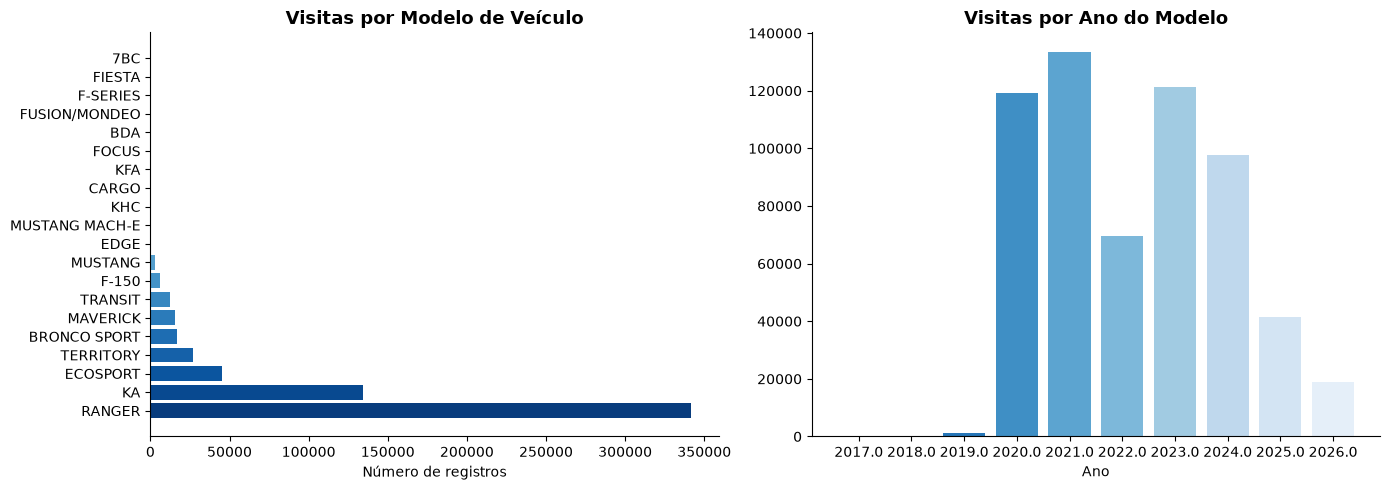

In [4]:
# 3.2 Distribuição de manutenções por modelo e ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_counts = df_raw['ModelName'].value_counts()
axes[0].barh(model_counts.index, model_counts.values,
             color=sns.color_palette("Blues_r", len(model_counts)))
axes[0].set_title("Visitas por Modelo de Veículo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de registros")

year_counts = df_raw['ModelYear'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color=sns.color_palette("Blues_r", len(year_counts)))
axes[1].set_title("Visitas por Ano do Modelo", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Ano")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_distribuicao.png", dpi=150, bbox_inches='tight')
plt.show()

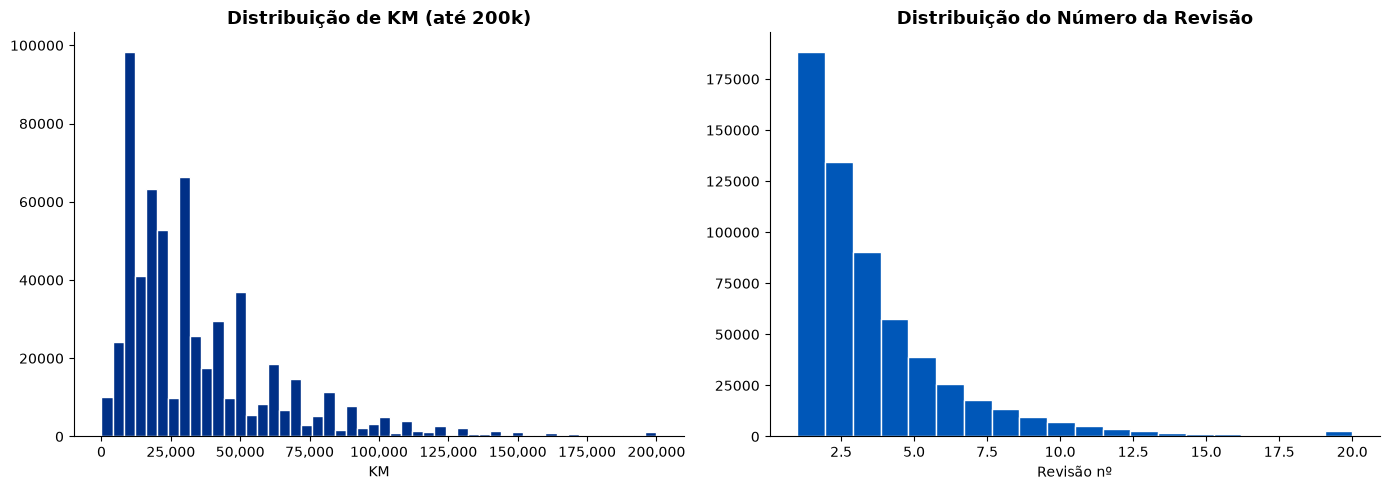

In [5]:
# 3.3 Distribuição de quilometragem e revisões
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['KM'].clip(upper=200_000), bins=50, color='#003087', edgecolor='white')
axes[0].set_title("Distribuição de KM (até 200k)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("KM")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(df_raw['MaintenanceNumber'].clip(upper=20), bins=20, color='#0057B8', edgecolor='white')
axes[1].set_title("Distribuição do Número da Revisão", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Revisão nº")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_km_revisoes.png", dpi=150, bbox_inches='tight')
plt.show()

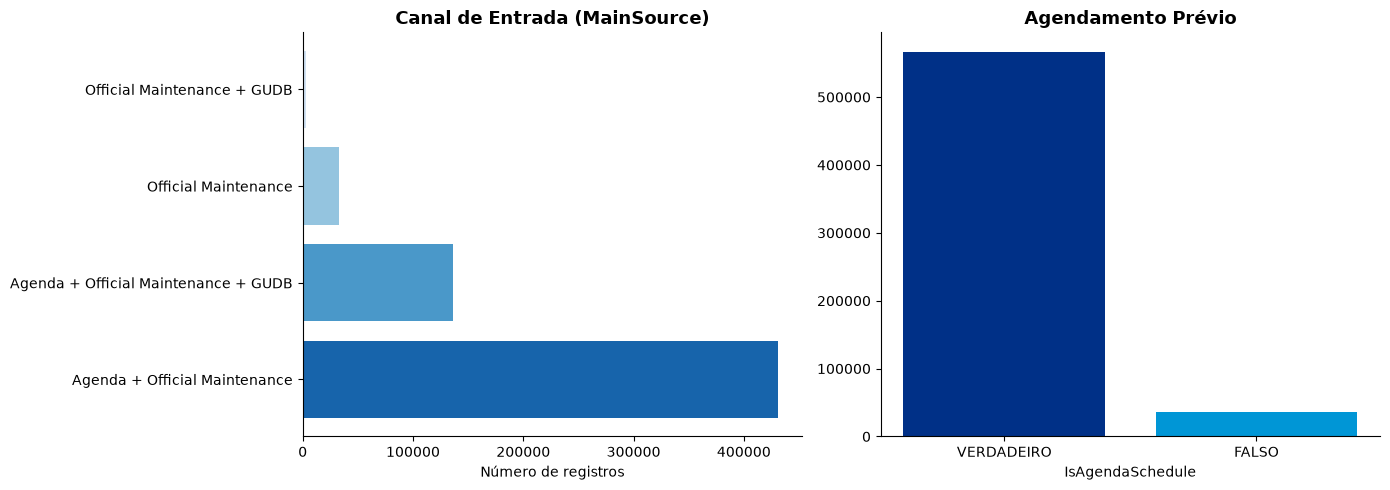

In [6]:
# 3.4 Canal de entrada e agendamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = df_raw['MainSource'].value_counts()
axes[0].barh(source_counts.index, source_counts.values,
             color=sns.color_palette("Blues_r", len(source_counts)))
axes[0].set_title("Canal de Entrada (MainSource)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de registros")

agenda_counts = df_raw['IsAgendaSchedule'].value_counts()
axes[1].bar(agenda_counts.index, agenda_counts.values,
            color=['#003087', '#0096D6'])
axes[1].set_title("Agendamento Prévio", fontsize=13, fontweight='bold')
axes[1].set_xlabel("IsAgendaSchedule")

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_canal_agendamento.png", dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Checagem de qualidade: valores suspeitos em `MaintenanceNumber`

`MaintenanceNumber` indica o número da revisão (1ª, 2ª, 3ª...). A distribuição esperada é decrescente — poucos veículos chegam às revisões mais altas. Vale conferir a cauda da distribuição.

> **Diagnóstico corrigido em relação à versão anterior do notebook.** Na versão da Sprint 1 atribuímos o cluster minúsculo que surgia com K=4 a "KM absurdo". Ao reexecutar a análise, o cluster pequeno tinha `max_revisao ≈ 98`, e não KM extremo — a causa é o código de revisão **99**, tratado a seguir.

Registros por MaintenanceNumber (cauda >= 40):
MaintenanceNumber
40       16
43        1
44        2
45        2
48        4
50       18
51        4
52      115
53        9
54        1
65       27
67        8
68        8
81        1
99     1419
100       3

Registros com MaintenanceNumber >= 90: 1,422 (0.24% dos registros) em 1,270 VINs


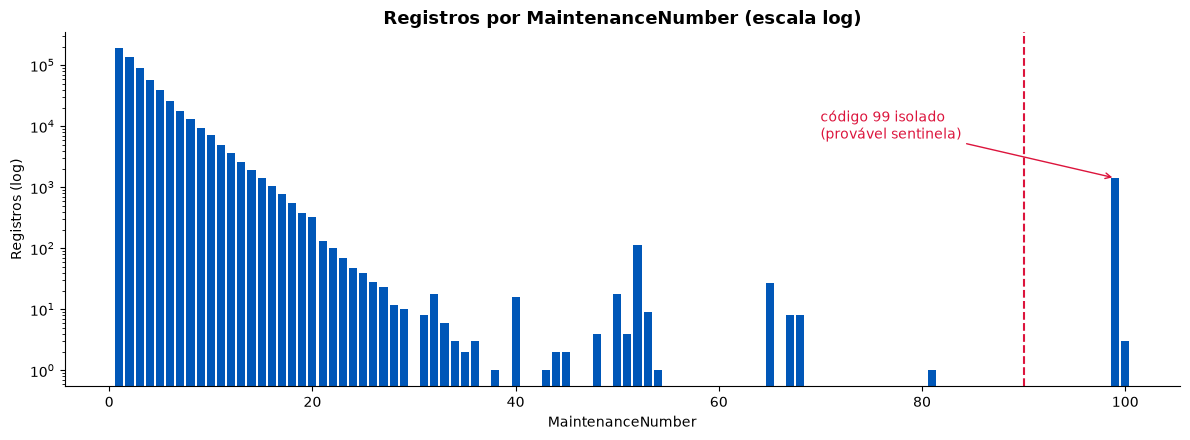

In [7]:
# 3.5 Qualidade dos dados: cauda de MaintenanceNumber
mn = df_raw['MaintenanceNumber'].value_counts().sort_index()
print("Registros por MaintenanceNumber (cauda >= 40):")
print(mn[mn.index >= 40].to_string())

SENTINELA_REVISAO = 90   # valores >= 90 tratados como código inválido/sentinela
mask_sent = df_raw['MaintenanceNumber'] >= SENTINELA_REVISAO
print(f"\nRegistros com MaintenanceNumber >= {SENTINELA_REVISAO}: {mask_sent.sum():,} "
      f"({mask_sent.mean()*100:.2f}% dos registros) em {df_raw.loc[mask_sent, 'VIN_Hash'].nunique():,} VINs")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(mn.index.astype(int), mn.values, color='#0057B8')
ax.set_yscale('log')
ax.axvline(SENTINELA_REVISAO, color='crimson', ls='--', lw=1.5)
ax.annotate("código 99 isolado\n(provável sentinela)", xy=(99, mn.loc[99]), xytext=(70, mn.max()/30),
            arrowprops=dict(arrowstyle='->', color='crimson'), color='crimson', fontsize=10)
ax.set_title("Registros por MaintenanceNumber (escala log)", fontsize=13, fontweight='bold')
ax.set_xlabel("MaintenanceNumber"); ax.set_ylabel("Registros (log)")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda_maintenance_number.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Pré-processamento — Base 1 (Histórico Completo)

### Tratamentos aplicados

| Problema | Evidência | Tratamento |
|---|---|---|
| KM fisicamente impossível | Registros com KM ≥ 1.000.000 | Registros removidos |
| Código de revisão inválido | `MaintenanceNumber` = 99/100 isolados no fim da escala (seção 3.5) | Convertido para nulo antes de calcular `max_revisao`; nulo imputado pela mediana |
| Outliers residuais na agregação | Ex.: `km_percorrido` chegando a ~944 mil km; veículos com >170 visitas | Winsorização no percentil 99,9 (apenas nas features do clustering — seção 5.0) |
| Nulos em datas/KM | Ver seção 3.1 | Mediana nas features derivadas; `garantia_ativa` = 0 se a data de garantia é nula |

### Estratégia de Agregação

Cada veículo (`VIN_Hash`) pode ter múltiplos registros de visita. Agregamos essas visitas
em **uma linha por veículo**, criando features que descrevam o comportamento histórico completo.
Esta tabela agregada é a **Base 1** — usada exclusivamente na etapa de segmentação.

In [8]:
# Filtragem de outliers de KM
km_antes = len(df_raw)
df_clean = df_raw[df_raw['KM'] < 1_000_000].copy()
print(f"Registros antes da filtragem: {km_antes:,}")
print(f"Registros removidos (KM ≥ 1.000.000): {km_antes - len(df_clean):,}")
print(f"Registros após filtragem:     {len(df_clean):,}")
print(f"VINs únicos após filtragem:   {df_clean['VIN_Hash'].nunique():,}")

# Códigos sentinela de revisão -> nulo (não entram em max_revisao / revisoes_distintas)
df_clean['MaintenanceNumberValido'] = df_clean['MaintenanceNumber'].where(df_clean['MaintenanceNumber'] < SENTINELA_REVISAO)
print(f"Registros com número de revisão invalidado: {df_clean['MaintenanceNumberValido'].isna().sum():,}")

# Sanidade: datas de venda/entrega/garantia são constantes por VIN?
for col in ['SalesDate', 'DeliveryDate', 'WarrantyStartDate', 'ModelYear']:
    pct = (df_clean.groupby('VIN_Hash')[col].nunique(dropna=True) > 1).mean() * 100
    print(f"VINs com mais de um valor de {col}: {pct:.2f}%")

Registros antes da filtragem: 602,788
Registros removidos (KM ≥ 1.000.000): 2,582
Registros após filtragem:     600,206
VINs únicos após filtragem:   175,137
Registros com número de revisão invalidado: 1,422
VINs com mais de um valor de SalesDate: 0.39%
VINs com mais de um valor de DeliveryDate: 0.00%
VINs com mais de um valor de WarrantyStartDate: 0.00%
VINs com mais de um valor de ModelYear: 0.00%


In [9]:
# Agregação por VIN
df_sorted = df_clean.sort_values(['VIN_Hash', 'ServiceDate'])

base1 = df_sorted.groupby('VIN_Hash').agg(
    # Comportamento pós-venda
    total_visitas          = ('MaintenanceID',          'count'),
    max_revisao            = ('MaintenanceNumberValido', 'max'),
    revisoes_distintas     = ('MaintenanceNumberValido', 'nunique'),
    km_na_ultima_visita    = ('KM',                     'max'),
    km_na_primeira_visita  = ('KM',                     'min'),
    dealers_visitados      = ('DealerCode',             'nunique'),
    dealer_ultima_visita   = ('DealerCode',             'last'),
    primeira_visita        = ('ServiceDate',            'min'),
    ultima_visita          = ('ServiceDate',            'max'),
    # Dados de compra
    modelo                 = ('ModelName',              'first'),
    ano_modelo             = ('ModelYear',              'first'),
    data_venda             = ('SalesDate',              'first'),
    data_garantia          = ('WarrantyStartDate',      'first'),
).reset_index()

# Features derivadas
base1['dias_entre_visitas']  = (base1['ultima_visita'] - base1['primeira_visita']).dt.days.fillna(0)
base1['km_percorrido']       = (base1['km_na_ultima_visita'] - base1['km_na_primeira_visita']).clip(lower=0)
base1['dias_desde_ultima']   = (DATA_REF - base1['ultima_visita']).dt.days
base1['idade_veiculo_anos']  = DATA_REF.year - base1['ano_modelo']
base1['km_por_visita']       = base1['km_percorrido'] / base1['total_visitas'].replace(0, np.nan)
base1['garantia_ativa']      = ((DATA_REF - base1['data_garantia']).dt.days < 365 * 3).astype(int)

# Tratamento de nulos (atribuição explícita: compatível com pandas 2.x e 3.x)
for col in ['max_revisao', 'km_percorrido', 'km_por_visita', 'dias_desde_ultima',
            'dias_entre_visitas', 'idade_veiculo_anos']:
    base1[col] = base1[col].fillna(base1[col].median())

print(f"Base 1 shape: {base1.shape}")
print(f"Nulos nas features de clustering/derivadas: "
      f"{base1[['total_visitas','max_revisao','dias_entre_visitas','km_percorrido','dias_desde_ultima','dealers_visitados','garantia_ativa','idade_veiculo_anos']].isnull().sum().sum()}")
base1.head()

Base 1 shape: (175137, 20)
Nulos nas features de clustering/derivadas: 0


,VIN_Hash,total_visitas,max_revisao,revisoes_distintas,km_na_ultima_visita,km_na_primeira_visita,dealers_visitados,dealer_ultima_visita,primeira_visita,ultima_visita,modelo,ano_modelo,data_venda,data_garantia,dias_entre_visitas,km_percorrido,dias_desde_ultima,idade_veiculo_anos,km_por_visita,garantia_ativa
0,00008eef200a0a71fd52b4b0bd43c6e275b50a8fe56a6f...,1,1.0,1,11010.0,11010.0,1,3050,2022-03-03,2022-03-03,KA,2021.0,2021-01-22,2021-01-22,0,0.0,1523,5.0,0.000000,0
1,0000a048f5503e31fd931282b6f932507b5a7e02bf4de6...,1,1.0,1,15543.0,15543.0,1,6124,2025-11-19,2025-11-19,RANGER,2025.0,2025-03-18,2025-03-18,0,0.0,166,1.0,0.000000,1
2,00015a2ad3fd2a788fb2ccf83b443e5326b3d835b53468...,1,1.0,1,9462.0,9462.0,1,2606,2020-11-16,2020-11-16,RANGER,2020.0,2020-02-10,2020-02-10,0,0.0,1995,6.0,0.000000,0
3,00028f8619d418ce4614ca8637d870db50eeb42f22562f...,1,1.0,1,15962.0,15962.0,1,5305,2026-03-09,2026-03-09,RANGER,2026.0,2025-04-17,2025-04-24,0,0.0,56,0.0,0.000000,1
4,0002a2d7b0e64c34a5cd3fdc69c387d28128474230d897...,3,5.0,3,50605.0,20375.0,1,5650,2022-04-13,2023-09-21,KA,2021.0,2020-11-09,2020-11-09,526,30230.0,956,5.0,10076.666667,0


## 5. Segmentação Comportamental (Não Supervisionado)

### 5.0 Features selecionadas para clustering

| Feature | Justificativa |
|---|---|
| `total_visitas` | Frequência de retorno à rede |
| `max_revisao` | Estágio de relacionamento com a Ford |
| `dias_entre_visitas` | Regularidade das visitas |
| `km_percorrido` | Intensidade de uso do veículo |
| `dias_desde_ultima` | Recência — tempo desde o último contato |
| `dealers_visitados` | Fidelidade a uma concessionária |
| `garantia_ativa` | Motivador de retorno à rede |
| `idade_veiculo_anos` | Ciclo de vida do veículo |

O K-Means é sensível a escala e a outliers; por isso aplicamos **winsorização (p99,9)** em `km_percorrido` e `total_visitas` e depois **padronização** (`StandardScaler`). Como a etapa é não supervisionada, os parâmetros de escala são ajustados na base inteira (não há conjunto de teste envolvido).

In [10]:
FEATURES_CLUSTER = [
    'total_visitas',
    'max_revisao',
    'dias_entre_visitas',
    'km_percorrido',
    'dias_desde_ultima',
    'dealers_visitados',
    'garantia_ativa',
    'idade_veiculo_anos',
]

X_cluster = base1[FEATURES_CLUSTER].copy()
X_cluster = X_cluster.fillna(X_cluster.median())

# Winsorização dos outliers residuais
for col in ['km_percorrido', 'total_visitas']:
    limite = X_cluster[col].quantile(0.999)
    n_cortados = (X_cluster[col] > limite).sum()
    X_cluster[col] = X_cluster[col].clip(upper=limite)
    print(f"{col:15s}: teto (p99,9) = {limite:,.0f}  |  {n_cortados} veículos ajustados")

print(f"\nNaNs em X_cluster: {X_cluster.isnull().sum().sum()}")  # deve ser 0

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)
print("Shape para clustering:", X_scaled.shape)

km_percorrido  : teto (p99,9) = 262,574  |  176 veículos ajustados
total_visitas  : teto (p99,9) = 42  |  165 veículos ajustados

NaNs em X_cluster: 0
Shape para clustering: (175137, 8)


  K=2 ✓  inércia=54337  silhouette=0.3897  davies-bouldin=1.0985
  K=3 ✓  inércia=35376  silhouette=0.4535  davies-bouldin=1.0107
  K=4 ✓  inércia=29252  silhouette=0.4347  davies-bouldin=1.1289
  K=5 ✓  inércia=26190  silhouette=0.3849  davies-bouldin=1.1493
  K=6 ✓  inércia=23481  silhouette=0.3825  davies-bouldin=1.1829
  K=7 ✓  inércia=21370  silhouette=0.3857  davies-bouldin=1.1533
  K=8 ✓  inércia=19723  silhouette=0.3839  davies-bouldin=1.1476


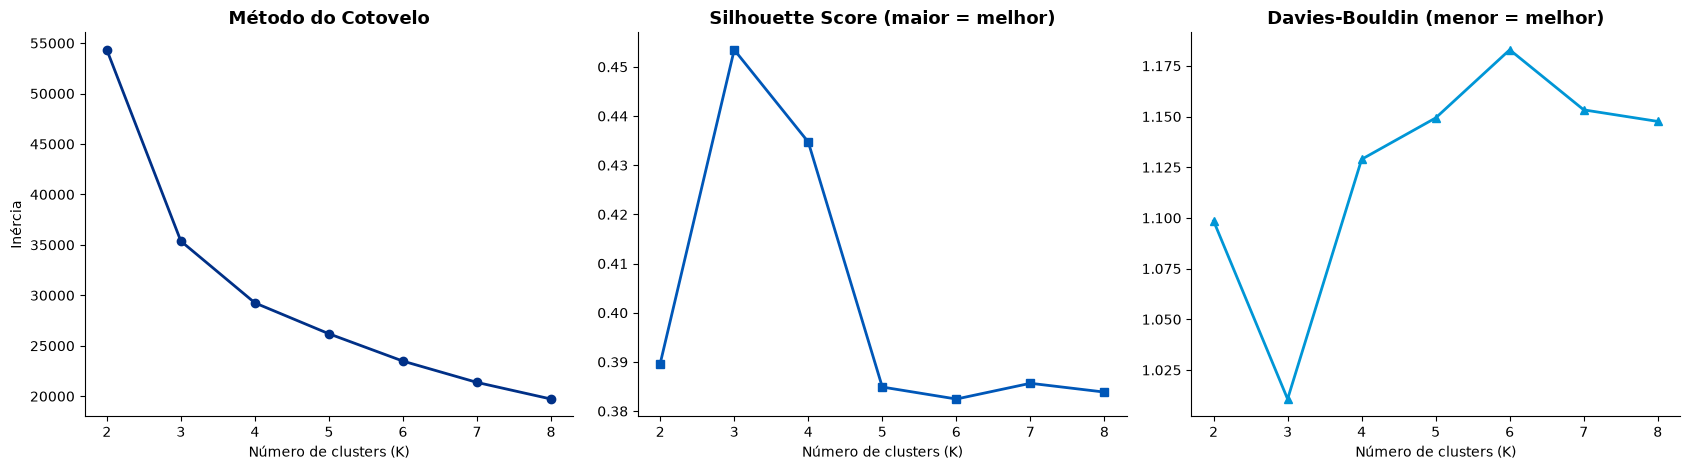


📊 Melhor K pelo Silhouette: 3
ℹ️  Amostra: 10,000 de 175,137 registros (5.7%)


In [11]:
# 5.1 Método do Cotovelo + Silhouette + Davies-Bouldin (amostra para performance)
# Silhouette é O(n²) — inviável em 175k linhas; 10k amostras bastam para comparar valores de K.

SAMPLE_SIZE = 10_000
idx_sample = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[idx_sample]

inertias, silhouettes, dbs = [], [], []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))
    dbs.append(davies_bouldin_score(X_sample, labels))
    print(f"  K={k} ✓  inércia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}  davies-bouldin={dbs[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].plot(ks, inertias, 'o-', color='#003087', linewidth=2)
axes[0].set_title("Método do Cotovelo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de clusters (K)"); axes[0].set_ylabel("Inércia")
axes[1].plot(ks, silhouettes, 's-', color='#0057B8', linewidth=2)
axes[1].set_title("Silhouette Score (maior = melhor)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Número de clusters (K)")
axes[2].plot(ks, dbs, '^-', color='#0096D6', linewidth=2)
axes[2].set_title("Davies-Bouldin (menor = melhor)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Número de clusters (K)")
plt.tight_layout()
plt.savefig(FIG_DIR / "cluster_escolha_k.png", dpi=150, bbox_inches='tight')
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"\n📊 Melhor K pelo Silhouette: {best_k}")
print(f"ℹ️  Amostra: {SAMPLE_SIZE:,} de {len(X_scaled):,} registros ({SAMPLE_SIZE/len(X_scaled)*100:.1f}%)")

### 5.2 Decisão sobre o número de clusters (K)

A hipótese inicial da Ford propõe **4 perfis**. Comparamos K=3 e K=4 sobre exatamente os mesmos dados tratados (código de revisão 99 invalidado e outliers winsorizados).

> **Correção em relação à versão da Sprint 1.** Naquela versão, o K=4 era descartado por gerar um cluster "de 3 registros com KM > 700 milhões". Ao reexecutar a análise sobre a base exportada, **não conseguimos reproduzir essa explicação**: o cluster pequeno do K=4 tinha ~1,3 mil veículos (0,75% da base) com `max_revisao ≈ 98` — efeito do código sentinela 99 (seção 3.5), e não de KM extremo. Com o código tratado, esse cluster espúrio desaparece e a comparação passa a ser feita com dados limpos.

In [12]:
# 5.2 Comparação K=3 vs K=4 na base completa (mesmos dados tratados)
comparacao_k = {}
for k in (3, 4):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    lab = km_tmp.labels_
    cent = pd.DataFrame(scaler_cluster.inverse_transform(km_tmp.cluster_centers_), columns=FEATURES_CLUSTER)
    cent.insert(0, 'n_veiculos', np.bincount(lab))
    cent.insert(1, '% base', (np.bincount(lab) / len(lab) * 100).round(1))
    comparacao_k[k] = dict(
        silhouette=silhouette_score(X_scaled[idx_sample], lab[idx_sample]),
        davies_bouldin=davies_bouldin_score(X_scaled[idx_sample], lab[idx_sample]),
        centroides=cent.round(1),
    )
    print(f"K={k} | silhouette={comparacao_k[k]['silhouette']:.4f} | davies-bouldin={comparacao_k[k]['davies_bouldin']:.4f}")
    print(comparacao_k[k]['centroides'].to_string())
    print()

K=3 | silhouette=0.4534 | davies-bouldin=1.0107
   n_veiculos  % base  total_visitas  max_revisao  dias_entre_visitas  km_percorrido  dias_desde_ultima  dealers_visitados  garantia_ativa  idade_veiculo_anos
0       70093    40.0            2.3          2.0               186.3        13660.6              158.8                1.1             1.0                 1.5
1       35823    20.5            7.8          7.5              1066.0        66126.4              387.8                1.9             0.1                 4.3
2       69221    39.5            2.3          2.4               344.1        12632.5             1330.9                1.3             0.0                 5.3

K=4 | silhouette=0.4395 | davies-bouldin=1.1427
   n_veiculos  % base  total_visitas  max_revisao  dias_entre_visitas  km_percorrido  dias_desde_ultima  dealers_visitados  garantia_ativa  idade_veiculo_anos
0       70418    40.2            2.3          2.0               187.5        14026.8              158.5     

### Decisão: K = 3

| Critério | K = 3 | K = 4 |
|---|---|---|
| Silhouette (maior = melhor) | **0,453** | 0,440 |
| Davies-Bouldin (menor = melhor) | **1,011** | 1,143 |
| Perfis acionáveis | 3, com ações de retenção distintas (seção 7) | 4 |

1. **O K=3 tem a melhor separação** em ambos os índices, e o gráfico da seção 5.1 mostra queda de silhouette a partir de K=4 (≈0,38 para K ≥ 5).
2. **O K=4 não é "ruim" — ele detalha o grupo com histórico de visitas**: separa os *Fiéis intensivos* (~12 visitas, ~101 mil km, 7% da base) de um grupo intermediário *em declínio* (~4,7 visitas, ~600 dias sem retornar, garantia vencida, 22,6% da base). É uma evolução natural do trabalho e fica registrada como trabalho futuro.
3. **Para a etapa supervisionada**, mais uma classe intermediária de fronteira difusa aumentaria a dificuldade da classificação sem ganho de ação imediato.

Ou seja: a hipótese de 4 perfis da Ford **não é refutada**, mas os dados sustentam com mais clareza **3 perfis** — e o K=4 mostra onde estão os subgrupos a explorar.

In [13]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
base1['cluster'] = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled[idx_sample], base1['cluster'].values[idx_sample])
db  = davies_bouldin_score(X_scaled[idx_sample], base1['cluster'].values[idx_sample])

print(f"K = {K_FINAL}")
print(f"Silhouette Score:     {sil:.4f}  (quanto mais alto, mais separados)")
print(f"Davies-Bouldin Score: {db:.4f}  (quanto mais baixo, melhor)")
print()
print("Distribuição dos clusters:")
print(base1['cluster'].value_counts().sort_index())

K = 3
Silhouette Score:     0.4534  (quanto mais alto, mais separados)
Davies-Bouldin Score: 1.0107  (quanto mais baixo, melhor)

Distribuição dos clusters:
cluster
0    69253
1    35787
2    70097
Name: count, dtype: int64


In [14]:
# 5.3 Centroides — BASE para o mapeamento de perfis
centroides = pd.DataFrame(
    scaler_cluster.inverse_transform(km_final.cluster_centers_),
    columns=FEATURES_CLUSTER
)
centroides.index.name = 'cluster'
print("Centroides (valores originais):")
centroides.round(1)

Centroides (valores originais):


,total_visitas,max_revisao,dias_entre_visitas,km_percorrido,dias_desde_ultima,dealers_visitados,garantia_ativa,idade_veiculo_anos
cluster,,,,,,,,
0,2.3,2.4,344.6,12645.7,1330.2,1.3,0.0,5.3
1,7.8,7.5,1066.2,66172.0,387.7,1.9,0.1,4.3
2,2.3,2.0,186.3,13663.3,158.8,1.1,1.0,1.5


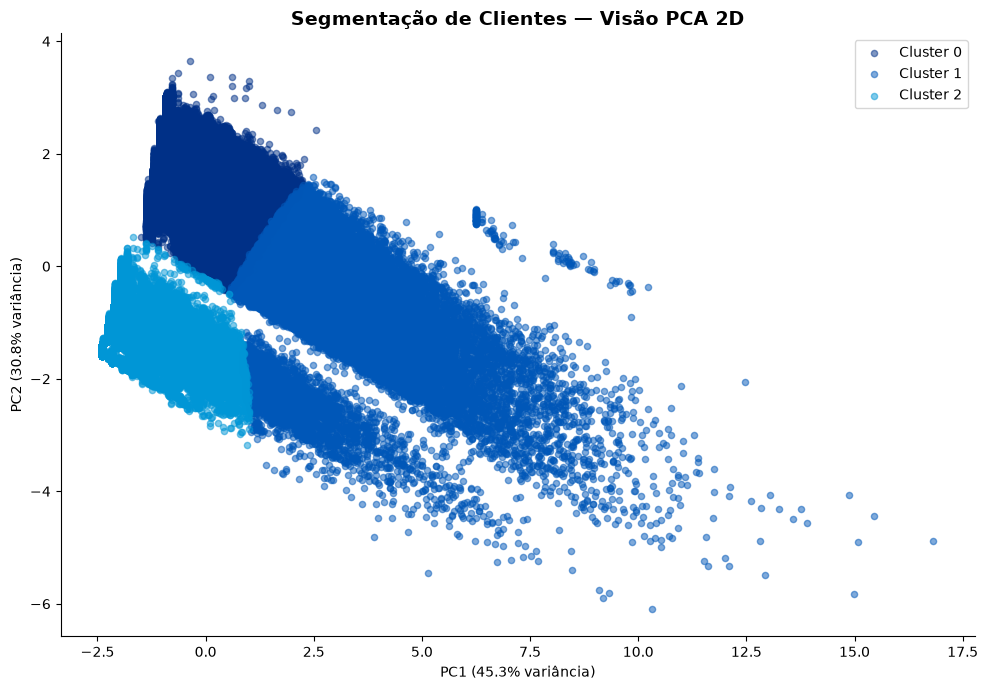

In [15]:
# 5.4 Visualização PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

base1['pca1'] = X_pca[:, 0]
base1['pca2'] = X_pca[:, 1]

cores = ['#003087', '#0057B8', '#0096D6']
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_FINAL):
    mask = base1['cluster'] == c
    ax.scatter(base1.loc[mask, 'pca1'], base1.loc[mask, 'pca2'],
               s=20, alpha=0.5, color=cores[c], label=f'Cluster {c}')

ax.set_title("Segmentação de Clientes — Visão PCA 2D", fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "clusters_pca.png", dpi=150, bbox_inches='tight')
plt.show()

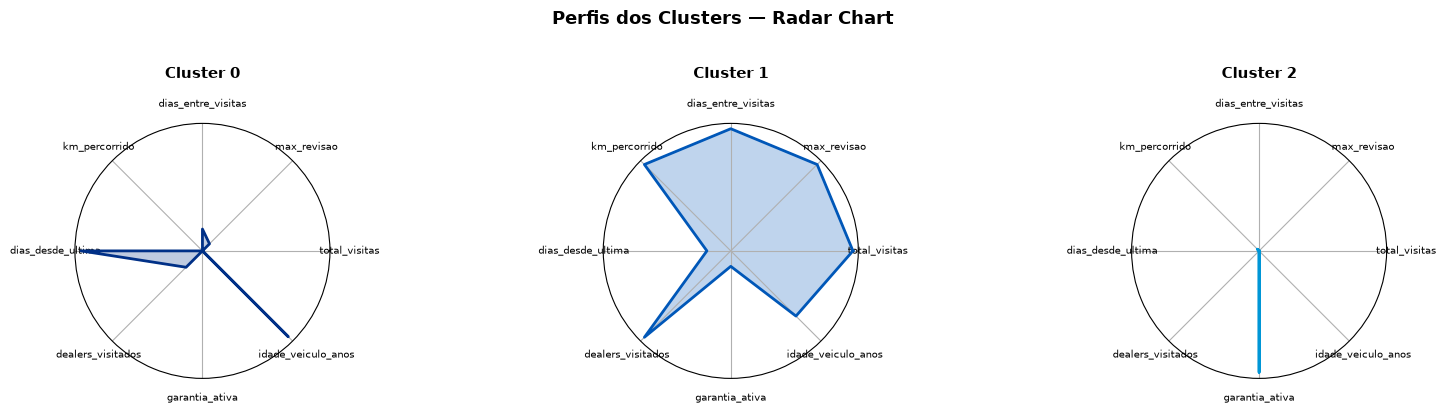

In [16]:
# 5.5 Radar chart dos perfis
cats = FEATURES_CLUSTER
N = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_FINAL, figsize=(16, 4), subplot_kw=dict(polar=True))
cores_radar = ['#003087', '#0057B8', '#0096D6']

for c in range(K_FINAL):
    vals = centroides.loc[c].values.tolist()
    mins = centroides.min().values
    maxs = centroides.max().values
    vals_norm = [(v - mi) / (ma - mi + 1e-9) for v, mi, ma in zip(vals, mins, maxs)]
    vals_norm += vals_norm[:1]

    axes[c].plot(angles, vals_norm, color=cores_radar[c], linewidth=2)
    axes[c].fill(angles, vals_norm, color=cores_radar[c], alpha=0.25)
    axes[c].set_xticks(angles[:-1])
    axes[c].set_xticklabels(cats, size=7)
    axes[c].set_yticks([])
    axes[c].set_title(f"Cluster {c}", fontsize=11, fontweight='bold', pad=15)

plt.suptitle("Perfis dos Clusters — Radar Chart", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "clusters_radar.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Mapeamento dos Perfis de Negócio

Cada cluster é interpretado a partir dos seus centroides (seção 5.3). O mapeamento é feito **por regras sobre os centroides** — e não por índices fixos — porque o número do cluster muda conforme a semente e a versão da biblioteca:

- **Cliente Fiel**: cluster com o maior número médio de visitas.
- **Cliente Esquecido**: entre os demais, o de maior proporção de garantia ativa (veículos novos, ainda dentro da garantia).
- **Cliente de Abandono**: o restante (poucas visitas e longo tempo sem retornar).

In [17]:
cent = centroides.copy()
c_fiel      = cent['total_visitas'].idxmax()
restantes   = [c for c in cent.index if c != c_fiel]
c_esquecido = cent.loc[restantes, 'garantia_ativa'].idxmax()
c_abandono  = [c for c in restantes if c != c_esquecido][0]

MAPA_PERFIS = {c_abandono: "Cliente de Abandono", c_esquecido: "Cliente Esquecido", c_fiel: "Cliente Fiel"}

# Verificações de sanidade do mapeamento (falham se a interpretação deixar de fazer sentido)
assert cent.loc[c_esquecido, 'dias_desde_ultima'] < cent.loc[c_abandono, 'dias_desde_ultima']
assert cent.loc[c_fiel, 'total_visitas'] > cent.loc[c_esquecido, 'total_visitas']

base1['perfil'] = base1['cluster'].map(MAPA_PERFIS)
print("Mapeamento cluster → perfil:", MAPA_PERFIS)
print()
print("Distribuição dos perfis:")
print(base1['perfil'].value_counts())
print()
resumo = base1.groupby('perfil')[FEATURES_CLUSTER].mean().round(2)
print("Média das features por perfil:")
resumo

Mapeamento cluster → perfil: {0: 'Cliente de Abandono', 2: 'Cliente Esquecido', 1: 'Cliente Fiel'}

Distribuição dos perfis:
perfil
Cliente Esquecido      70097
Cliente de Abandono    69253
Cliente Fiel           35787
Name: count, dtype: int64

Média das features por perfil:


,total_visitas,max_revisao,dias_entre_visitas,km_percorrido,dias_desde_ultima,dealers_visitados,garantia_ativa,idade_veiculo_anos
perfil,,,,,,,,
Cliente Esquecido,2.28,1.97,186.19,13650.77,158.79,1.14,1.00,1.47
Cliente Fiel,7.89,7.52,1066.14,67027.18,387.23,1.87,0.13,4.34
Cliente de Abandono,2.28,2.43,344.67,12650.58,1330.11,1.28,0.00,5.27


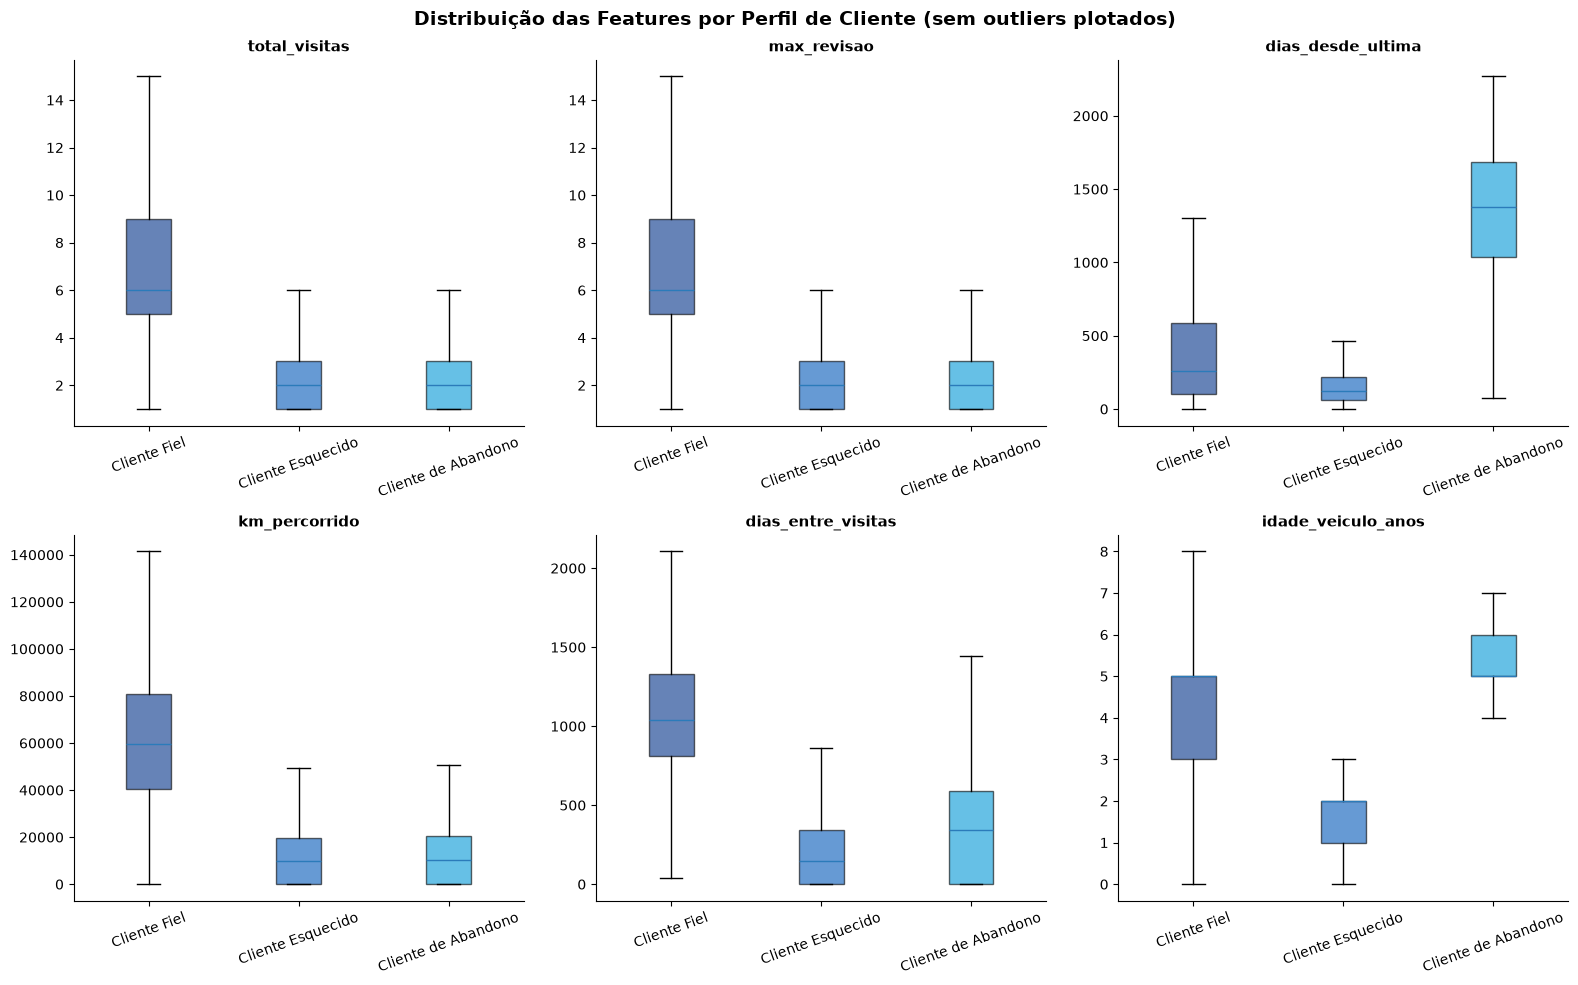

In [18]:
# Boxplots das principais features por perfil
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_plot = ['total_visitas', 'max_revisao', 'dias_desde_ultima',
                 'km_percorrido', 'dias_entre_visitas', 'idade_veiculo_anos']
perfis_ordem = ['Cliente Fiel', 'Cliente Esquecido', 'Cliente de Abandono']

for i, feat in enumerate(features_plot):
    data_plot = [base1[base1['perfil'] == p][feat].values for p in perfis_ordem]
    bp = axes[i].boxplot(data_plot, patch_artist=True, showfliers=False)
    axes[i].set_xticklabels(perfis_ordem, rotation=20)
    for patch, color in zip(bp['boxes'], ['#003087', '#0057B8', '#0096D6']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')

plt.suptitle("Distribuição das Features por Perfil de Cliente (sem outliers plotados)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "perfis_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Estratégias de Retenção por Perfil

| Perfil | Comportamento observado | Risco de evasão | Ação sugerida |
|---|---|---|---|
| **Cliente Fiel** | Alta frequência, múltiplas revisões, presença recente na rede | 🟢 Baixo | Programa de fidelidade premium, agendamento antecipado automático, ofertas exclusivas de upgrade |
| **Cliente de Abandono** | 1–2 visitas, ausente há mais de 1 ano, garantia vencida | 🔴 Alto | Campanha de reativação via CRM, desconto progressivo na próxima revisão, contato proativo por WhatsApp/e-mail |
| **Cliente Esquecido** | Poucas visitas, garantia ativa, último contato recente | 🟡 Médio | Lembretes automáticos por KM/tempo, notificação push no app Ford Vision, oferta de agendamento com um clique |

> **Atenção à leitura do "Cliente Esquecido".** Ele reúne sobretudo veículos **novos** (garantia ativa) que ainda tiveram poucas visitas; o risco é *potencial* (a revisão pode simplesmente ainda não ter vencido), enquanto o "Abandono" já é uma evasão observada.

In [19]:
# Impacto potencial no VIN Share (calculado, não digitado)
total_vins = len(base1)
partes = base1['perfil'].value_counts()
for p in ['Cliente Fiel', 'Cliente Esquecido', 'Cliente de Abandono']:
    print(f"{p:22s}: {partes[p]:>7,} veículos ({partes[p]/total_vins*100:5.1f}%)")
risco = (partes['Cliente de Abandono'] + partes['Cliente Esquecido']) / total_vins * 100
print(f"\nBase nos perfis Abandono + Esquecido: {risco:.1f}% — oportunidade de ações segmentadas.")

Cliente Fiel          :  35,787 veículos ( 20.4%)
Cliente Esquecido     :  70,097 veículos ( 40.0%)
Cliente de Abandono   :  69,253 veículos ( 39.5%)

Base nos perfis Abandono + Esquecido: 79.6% — oportunidade de ações segmentadas.


## 8. Base 2 — Definição do Problema Supervisionado

### 8.1 Compreensão do problema

| Item | Definição |
|---|---|
| **Problema de negócio** | Priorizar, entre os veículos da base, aqueles com maior chance de estarem fora da rede oficial de manutenção (VIN Share) |
| **Objetivo do modelo** | Dado o cadastro de um veículo, estimar seu **perfil de pós-venda** (Fiel, Esquecido ou Abandono) sem depender do histórico de visitas |
| **Tipo de problema** | **Classificação multiclasse** (3 classes) |
| **Rótulo (alvo)** | Perfil obtido na segmentação K-Means (seção 5). São **pseudo-rótulos**: descrevem comportamento observado, não uma evasão medida por fonte externa |
| **Dados** | Registros reais de serviço da rede Ford Brasil (não sintéticos), uma linha por veículo após agregação |
| **Métrica principal** | **F1 macro** (as classes têm tamanhos diferentes) + acurácia e ROC-AUC (one-vs-rest), sempre comparados com baselines |

### Política de features

| Feature | Situação | Justificativa |
|---|---|---|
| `ano_modelo` | ✅ usada | Atributo cadastral do veículo |
| `ModelName` (one-hot) | ✅ usada | Linha do veículo (Ranger, Territory, Maverick...) |
| `dias_venda_entrega` | ✅ usada | Prazo logístico da venda (cadastro) |
| `dias_entrega_garantia` | ✅ usada | Prazo até ativação da garantia (cadastro) |
| `tempo_garantia_ate_hoje` | ✅ usada | Tempo decorrido desde o início da garantia, na data de pontuação |
| `idade_veiculo_proxy` | ⛔ removida | Redundante com `ano_modelo` |
| `MainSource`, `IsAgendaSchedule` | ⛔ removidas | Vêm da **primeira visita de serviço** (pós-venda) — não existem para um veículo ainda sem visitas |
| `KM`, `MaintenanceNumber` e demais features de visita | ⛔ removidas | Definem o próprio rótulo (seção 5) |

> ⚠️ **Circularidade a ser testada, não escondida.** O rótulo foi construído com `garantia_ativa` e `idade_veiculo_anos`, que são funções das mesmas datas/ano usadas por `tempo_garantia_ate_hoje` e `ano_modelo`. Espera-se, portanto, que essas duas features carreguem grande parte do sinal. Por isso o notebook inclui **baselines de uma feature** (9.2) e uma **análise de ablação** (9.7) que mostram quanto do desempenho vem delas e quanto vem do restante.

In [20]:
# 8.2 Construção da Base 2 — atributos cadastrais de cada veículo (1 linha por VIN)
cols_cadastro = ['VIN_Hash', 'ModelName', 'ModelYear', 'SalesDate', 'DeliveryDate', 'WarrantyStartDate']
base2_raw = (df_clean.sort_values(['VIN_Hash', 'ServiceDate'])[cols_cadastro]
             .groupby('VIN_Hash').first().reset_index())

# Junta o perfil (alvo) e a concessionária da última visita (usada na geração de leads)
base2 = base2_raw.merge(base1[['VIN_Hash', 'perfil', 'cluster', 'dealer_ultima_visita']],
                        on='VIN_Hash', how='inner')

# Engenharia de features
base2['ano_modelo'] = base2['ModelYear']
base2['ModelName'] = base2['ModelName'].fillna('DESCONHECIDO').astype(str).str.upper().str.strip()
base2['dias_venda_entrega']       = (base2['DeliveryDate'] - base2['SalesDate']).dt.days.clip(lower=0)
base2['dias_entrega_garantia']    = (base2['WarrantyStartDate'] - base2['DeliveryDate']).dt.days.clip(lower=0)
base2['tempo_garantia_ate_hoje']  = (DATA_REF - base2['WarrantyStartDate']).dt.days.clip(lower=0)

FEATURES_NUM_A = ['ano_modelo', 'dias_venda_entrega', 'dias_entrega_garantia', 'tempo_garantia_ate_hoje']
FEATURES_CAT_A = ['ModelName']
FS_BASE_ATIVA  = FEATURES_NUM_A + FEATURES_CAT_A          # modelo principal
FS_DIA_ZERO    = ['dias_venda_entrega', 'dias_entrega_garantia', 'ModelName']   # sensibilidade

print(f"Base 2 shape: {base2.shape}")
print("\nDistribuição do alvo (perfil):")
print(base2['perfil'].value_counts())
print((base2['perfil'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')
print("\nNulos nas features (imputados dentro do pipeline, apenas com estatísticas do treino):")
print(base2[FS_BASE_ATIVA].isnull().sum())
base2[FS_BASE_ATIVA + ['perfil']].head()

Base 2 shape: (175137, 13)

Distribuição do alvo (perfil):
perfil
Cliente Esquecido      70097
Cliente de Abandono    69253
Cliente Fiel           35787
Name: count, dtype: int64
perfil
Cliente Esquecido      40.0%
Cliente de Abandono    39.5%
Cliente Fiel           20.4%
Name: proportion, dtype: str

Nulos nas features (imputados dentro do pipeline, apenas com estatísticas do treino):
ano_modelo                   1
dias_venda_entrega         121
dias_entrega_garantia      121
tempo_garantia_ate_hoje    121
ModelName                    0
dtype: int64


,ano_modelo,dias_venda_entrega,dias_entrega_garantia,tempo_garantia_ate_hoje,ModelName,perfil
0,2021.0,0.0,0.0,1928.0,KA,Cliente de Abandono
1,2025.0,0.0,0.0,412.0,RANGER,Cliente Esquecido
2,2020.0,0.0,0.0,2275.0,RANGER,Cliente de Abandono
3,2026.0,7.0,0.0,375.0,RANGER,Cliente Esquecido
4,2021.0,0.0,0.0,2002.0,KA,Cliente de Abandono


## 9. Modelagem Preditiva (Supervisionado)

### 9.1 Divisão dos dados e pré-processamento

- **Split estratificado 80/20** (treino/teste). O conjunto de teste **só é usado para reportar resultados**: escolha de modelo e ajuste de hiperparâmetros usam **validação cruzada dentro do treino**.
- **Pré-processamento dentro de um `Pipeline`/`ColumnTransformer`**: imputação por mediana e padronização (numéricas) e one-hot (`ModelName`) são ajustados apenas com dados de treino em cada *fold* — sem vazamento estatístico.
- `ModelName` usa **one-hot** (não `LabelEncoder`), pois uma codificação ordinal inventaria uma ordem que não existe entre modelos de veículos.

In [21]:
def montar_preprocessador(features):
    num = [f for f in features if f != 'ModelName']
    cat = [f for f in features if f == 'ModelName']
    transformers = []
    if num:
        transformers.append(('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                                              ('sc',  StandardScaler())]), num))
    if cat:
        transformers.append(('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='DESCONHECIDO')),
                                              ('oh',  OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                    min_frequency=100, sparse_output=False))]), cat))
    return ColumnTransformer(transformers)

def montar_pipeline(features, clf):
    return Pipeline([('prep', montar_preprocessador(features)), ('clf', clf)])

df_tr, df_te = train_test_split(base2, test_size=0.2, random_state=RANDOM_STATE, stratify=base2['perfil'])
X_tr, y_tr = df_tr[FS_BASE_ATIVA], df_tr['perfil']
X_te, y_te = df_te[FS_BASE_ATIVA], df_te['perfil']

print(f"Treino: {X_tr.shape} | Teste: {X_te.shape}")
print("\nDistribuição do alvo (treino | teste):")
print(pd.concat([y_tr.value_counts(normalize=True).rename('treino'),
                 y_te.value_counts(normalize=True).rename('teste')], axis=1).round(3))

Treino: (140109, 5) | Teste: (35028, 5)

Distribuição do alvo (treino | teste):
                     treino  teste
perfil                            
Cliente Esquecido     0.400  0.400
Cliente de Abandono   0.395  0.395
Cliente Fiel          0.204  0.204


### 9.2 Baselines — quanto "vale" só acertar o óbvio?

Antes de comparar algoritmos, medimos três referências simples. Um modelo só é interessante se superar **com folga** o que essas referências já entregam.

1. **Classe majoritária** — sempre prevê o perfil mais comum.
2. **Só `ano_modelo`** (árvore rasa) — mede o quanto a idade do modelo já explica o perfil.
3. **Só `tempo_garantia_ate_hoje`** (árvore rasa) — mede o quanto o tempo de garantia decorrido já explica o perfil.

In [22]:
def avaliar(pipe, X, y, nome):
    y_pred = pipe.predict(X)
    proba = pipe.predict_proba(X)
    return {
        'modelo': nome,
        'accuracy': accuracy_score(y, y_pred),
        'f1_macro': f1_score(y, y_pred, average='macro'),
        'f1_weighted': f1_score(y, y_pred, average='weighted'),
        'roc_auc_ovr': roc_auc_score(y, proba, multi_class='ovr', average='macro', labels=list(pipe.classes_)),
    }

baselines = {
    'Baseline 1 — classe majoritária':
        montar_pipeline(['ano_modelo'], DummyClassifier(strategy='most_frequent')),
    'Baseline 2 — só ano_modelo (árvore rasa)':
        montar_pipeline(['ano_modelo'], DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
    'Baseline 3 — só tempo_garantia_ate_hoje (árvore rasa)':
        montar_pipeline(['tempo_garantia_ate_hoje'], DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
}
FEATS_BASELINE = {
    'Baseline 1 — classe majoritária': ['ano_modelo'],
    'Baseline 2 — só ano_modelo (árvore rasa)': ['ano_modelo'],
    'Baseline 3 — só tempo_garantia_ate_hoje (árvore rasa)': ['tempo_garantia_ate_hoje'],
}

resultados_teste = []
for nome, pipe in baselines.items():
    fs = FEATS_BASELINE[nome]
    pipe.fit(df_tr[fs], y_tr)
    resultados_teste.append(avaliar(pipe, df_te[fs], y_te, nome))

pd.DataFrame(resultados_teste).set_index('modelo').round(4)

,accuracy,f1_macro,f1_weighted,roc_auc_ovr
modelo,,,,
Baseline 1 — classe majoritária,0.4003,0.1906,0.2288,0.5000
Baseline 2 — só ano_modelo (árvore rasa),0.7908,0.7358,0.7889,0.8857
Baseline 3 — só tempo_garantia_ate_hoje (árvore rasa),0.8180,0.7451,0.8021,0.8959


### 9.3 Comparação de algoritmos (validação cruzada, 5 folds, dados de treino completos)

Cinco famílias de algoritmos, todas com o **mesmo pré-processamento e os mesmos folds**:

| Modelo | Por que está na comparação |
|---|---|
| Regressão Logística | Baseline linear, interpretável — mostra se há relações não lineares a capturar |
| Árvore de Decisão | Regras simples e explicáveis para a operação das concessionárias |
| Random Forest | *Bagging* de árvores; robusto a ruído e a variáveis correlacionadas (modelo da versão anterior) |
| Gradient Boosting (`HistGradientBoostingClassifier`) | *Boosting* de árvores — costuma liderar em dados tabulares; implementação por histogramas escala para 140 mil linhas |
| MLP (rede neural) | Representante de redes neurais, para comparar com os métodos de árvore |

**Critério de escolha:** maior **F1 macro** médio na validação cruzada (o conjunto de teste não participa da escolha).

Validação cruzada 5-fold em 140,109 registros de treino
------------------------------------------------------------------------------
Regressão Logística        | F1 macro 0.8072 ± 0.0010 | acc 0.8487 |   1.8s/fold
Árvore de Decisão          | F1 macro 0.8087 ± 0.0018 | acc 0.8556 |   0.6s/fold
Random Forest              | F1 macro 0.8060 ± 0.0014 | acc 0.8542 |   3.7s/fold
Gradient Boosting (Hist)   | F1 macro 0.8093 ± 0.0013 | acc 0.8557 |   3.6s/fold
MLP (rede neural)          | F1 macro 0.8093 ± 0.0017 | acc 0.8555 |  29.4s/fold


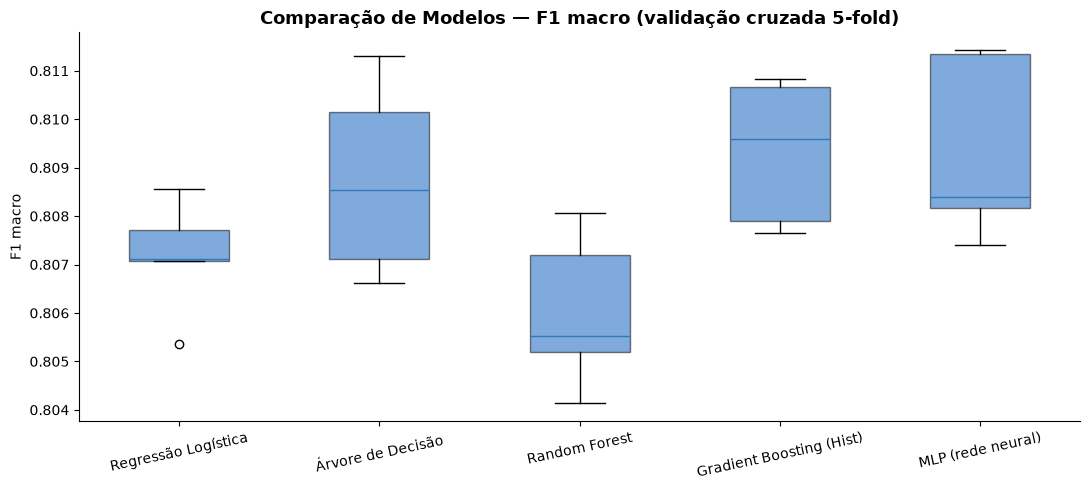

Modelos dentro da margem de empate técnico (±0.002): ['Árvore de Decisão', 'Gradient Boosting (Hist)', 'MLP (rede neural)']

🏆 Finalista (maior F1 macro; desempate por ordem de preferência pré-definida): Gradient Boosting (Hist)


,f1_macro_cv,f1_macro_std,accuracy_cv,tempo_fit_s
modelo,,,,
MLP (rede neural),0.8093,0.0017,0.8555,29.3855
Gradient Boosting (Hist),0.8093,0.0013,0.8557,3.6434
Árvore de Decisão,0.8087,0.0018,0.8556,0.6382
Regressão Logística,0.8072,0.0010,0.8487,1.8182
Random Forest,0.8060,0.0014,0.8542,3.7434


In [23]:
modelos = {
    'Regressão Logística':       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Árvore de Decisão':         DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=RANDOM_STATE),
    'Random Forest':             RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting (Hist)':  HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'MLP (rede neural)':         MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=60, n_iter_no_change=5,
                                               random_state=RANDOM_STATE),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

cv_scores, linhas_cv = {}, []
print(f"Validação cruzada 5-fold em {len(X_tr):,} registros de treino")
print("-" * 78)
for nome, clf in modelos.items():
    t0 = time.time()
    res = cross_validate(montar_pipeline(FS_BASE_ATIVA, clf), X_tr, y_tr, cv=cv5, scoring=scoring, n_jobs=1)
    cv_scores[nome] = res['test_f1_macro']
    linhas_cv.append({'modelo': nome,
                      'f1_macro_cv': res['test_f1_macro'].mean(), 'f1_macro_std': res['test_f1_macro'].std(),
                      'accuracy_cv': res['test_accuracy'].mean(), 'tempo_fit_s': res['fit_time'].mean()})
    print(f"{nome:26s} | F1 macro {res['test_f1_macro'].mean():.4f} ± {res['test_f1_macro'].std():.4f} "
          f"| acc {res['test_accuracy'].mean():.4f} | {res['fit_time'].mean():5.1f}s/fold")

cv_df = pd.DataFrame(linhas_cv).set_index('modelo')

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(list(cv_scores.values()), patch_artist=True, boxprops=dict(facecolor='#0057B8', alpha=0.5))
ax.set_xticklabels(list(cv_scores.keys()), rotation=12)
ax.set_title("Comparação de Modelos — F1 macro (validação cruzada 5-fold)", fontsize=13, fontweight='bold')
ax.set_ylabel("F1 macro")
plt.tight_layout()
plt.savefig(FIG_DIR / "comparacao_modelos.png", dpi=150, bbox_inches='tight')
plt.show()

# Critério de escolha: maior F1 macro médio na validação cruzada. Em caso de empate técnico
# (diferença menor que a tolerância abaixo, da ordem do desvio-padrão entre folds), o desempate
# usa uma ordem de preferência fixa — assim a escolha não muda entre versões do scikit-learn
# ou sistemas operacionais, onde arredondamentos de ponto flutuante podem inverter um empate
# desse tamanho.
TOL_EMPATE = 0.002
ORDEM_DESEMPATE = ['Gradient Boosting (Hist)', 'MLP (rede neural)', 'Árvore de Decisão',
                   'Regressão Logística', 'Random Forest']

melhor_score = cv_df['f1_macro_cv'].max()
empatados = cv_df[cv_df['f1_macro_cv'] >= melhor_score - TOL_EMPATE].index.tolist()
FINALISTA = next(m for m in ORDEM_DESEMPATE if m in empatados)

print(f"Modelos dentro da margem de empate técnico (±{TOL_EMPATE}): {empatados}")
print(f"\n🏆 Finalista (maior F1 macro; desempate por ordem de preferência pré-definida): {FINALISTA}")
cv_df.round(4).sort_values('f1_macro_cv', ascending=False)

### 9.4 Ajuste de hiperparâmetros do finalista

Busca aleatória (`RandomizedSearchCV`) sobre uma grade de configurações do modelo finalista, com **validação cruzada de 3 folds** no treino e **F1 macro** como métrica. Ao final, o melhor conjunto é reavaliado no **mesmo protocolo de 5 folds** da seção 9.3, para uma comparação justa "padrão × ajustado".

In [24]:
PARAM_DIST = {
    'Gradient Boosting (Hist)': {
        'clf__learning_rate':     [0.03, 0.05, 0.1, 0.2],
        'clf__max_leaf_nodes':    [15, 31, 63],
        'clf__min_samples_leaf':  [20, 50, 100, 200],
        'clf__l2_regularization': [0.0, 0.1, 1.0],
        'clf__max_iter':          [100, 200, 300],
    },
    'Random Forest': {
        'clf__n_estimators':     [100, 200],
        'clf__max_depth':        [8, 12, 16, None],
        'clf__min_samples_leaf': [2, 5, 10, 20],
        'clf__max_features':     ['sqrt', 0.5, 1.0],
    },
    'MLP (rede neural)': {
        'clf__hidden_layer_sizes': [(16,), (32, 16), (64, 32)],
        'clf__alpha':              [1e-5, 1e-4, 1e-3],
        'clf__learning_rate_init': [1e-3, 3e-3],
    },
    'Árvore de Decisão': {
        'clf__max_depth':        [4, 6, 8, 12],
        'clf__min_samples_leaf': [20, 50, 100, 200],
    },
    'Regressão Logística': {'clf__C': [0.01, 0.1, 1, 10, 100]},
}

grade = PARAM_DIST[FINALISTA]
n_total = int(np.prod([len(v) for v in grade.values()]))
N_ITER = min(12, n_total)

busca = RandomizedSearchCV(
    montar_pipeline(FS_BASE_ATIVA, clone(modelos[FINALISTA])),
    param_distributions=grade, n_iter=N_ITER, scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE, n_jobs=1, refit=True, return_train_score=False,
)
t0 = time.time()
busca.fit(X_tr, y_tr)
print(f"Busca concluída em {time.time()-t0:.0f}s — {N_ITER} configurações × 3 folds")
print(f"Melhores hiperparâmetros: {busca.best_params_}")

tabela_busca = (pd.DataFrame(busca.cv_results_)
                .sort_values('rank_test_score')
                [['rank_test_score', 'mean_test_score', 'std_test_score'] + [f'param_{k}' for k in grade]]
                .rename(columns=lambda c: c.replace('param_clf__', '')))
tabela_busca.head(8).round(4)

Busca concluída em 310s — 12 configurações × 3 folds
Melhores hiperparâmetros: {'clf__min_samples_leaf': 20, 'clf__max_leaf_nodes': 15, 'clf__max_iter': 100, 'clf__learning_rate': 0.05, 'clf__l2_regularization': 0.1}


,rank_test_score,mean_test_score,std_test_score,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization,max_iter
2,1,0.8095,0.0004,0.05,15,20,0.1,100
0,2,0.8093,0.0002,0.20,31,20,1.0,300
9,3,0.8093,0.0002,0.03,31,20,0.1,100
10,4,0.8092,0.0006,0.03,63,50,0.1,100
1,5,0.8092,0.0005,0.10,15,200,0.0,100
6,6,0.8092,0.0005,0.20,31,100,1.0,200
4,7,0.8090,0.0004,0.10,63,20,1.0,300
8,8,0.8090,0.0005,0.05,15,200,0.1,200


In [25]:
# Comparação justa padrão × ajustado (mesmo protocolo de 5 folds)
pipe_ajustado = busca.best_estimator_
nome_ajustado = f"{FINALISTA} — ajustado"
res_aj = cross_validate(clone(pipe_ajustado), X_tr, y_tr, cv=cv5, scoring=scoring, n_jobs=1)
cv_scores[nome_ajustado] = res_aj['test_f1_macro']

print(f"{FINALISTA:34s} padrão : F1 macro {cv_df.loc[FINALISTA, 'f1_macro_cv']:.4f}")
print(f"{nome_ajustado:34s} ajustado: F1 macro {res_aj['test_f1_macro'].mean():.4f} ± {res_aj['test_f1_macro'].std():.4f}")
ganho = res_aj['test_f1_macro'].mean() - cv_df.loc[FINALISTA, 'f1_macro_cv']
print(f"Ganho do ajuste: {ganho:+.4f} de F1 macro")

Gradient Boosting (Hist)           padrão : F1 macro 0.8093
Gradient Boosting (Hist) — ajustado ajustado: F1 macro 0.8096 ± 0.0014
Ganho do ajuste: +0.0003 de F1 macro


### 9.5 Avaliação no conjunto de teste — todos os modelos

Cada modelo é treinado no treino completo e avaliado **uma vez** no conjunto de teste (20% dos dados, nunca usados em treino nem no ajuste de hiperparâmetros). Métricas: acurácia, **F1 macro** (principal), F1 ponderado e **ROC-AUC one-vs-rest** (macro).

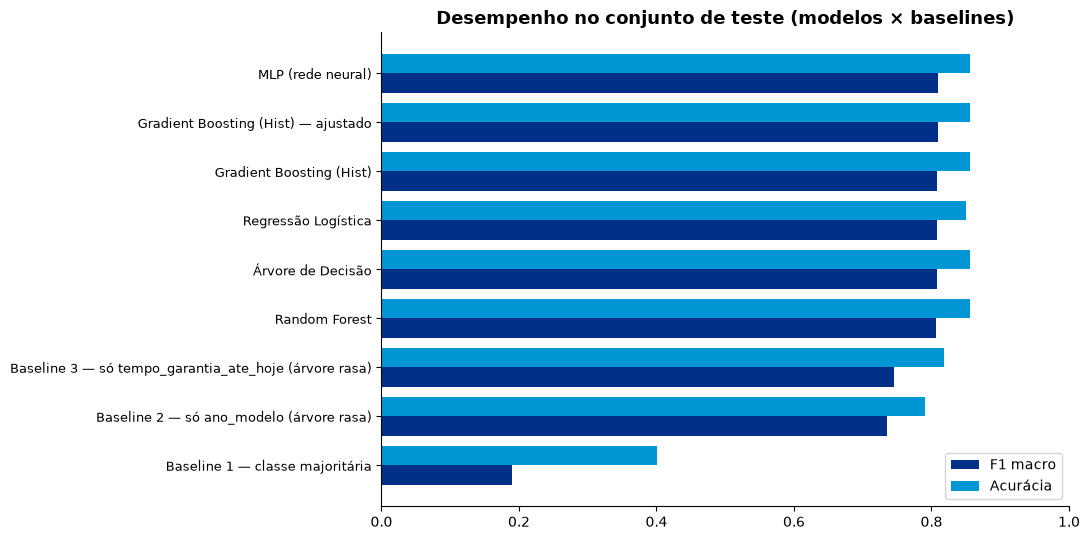

,accuracy,f1_macro,f1_weighted,roc_auc_ovr
modelo,,,,
MLP (rede neural),0.8555,0.8097,0.8491,0.9263
Gradient Boosting (Hist) — ajustado,0.8558,0.8091,0.8488,0.9265
Gradient Boosting (Hist),0.8554,0.8087,0.8485,0.9267
Regressão Logística,0.8499,0.8086,0.8465,0.9241
Árvore de Decisão,0.8553,0.8085,0.8484,0.9254
Random Forest,0.8553,0.8071,0.8477,0.9230
Baseline 3 — só tempo_garantia_ate_hoje (árvore rasa),0.8180,0.7451,0.8021,0.8959
Baseline 2 — só ano_modelo (árvore rasa),0.7908,0.7358,0.7889,0.8857
Baseline 1 — classe majoritária,0.4003,0.1906,0.2288,0.5000


In [26]:
for nome, clf in modelos.items():
    pipe = montar_pipeline(FS_BASE_ATIVA, clone(clf)).fit(X_tr, y_tr)
    resultados_teste.append(avaliar(pipe, X_te, y_te, nome))
resultados_teste.append(avaliar(pipe_ajustado, X_te, y_te, nome_ajustado))

tabela_teste = pd.DataFrame(resultados_teste).set_index('modelo')
display_tab = tabela_teste.sort_values('f1_macro', ascending=False).round(4)

fig, ax = plt.subplots(figsize=(11, 5.5))
ordem = tabela_teste.sort_values('f1_macro')
y_pos = np.arange(len(ordem))
ax.barh(y_pos - 0.2, ordem['f1_macro'], height=0.4, color='#003087', label='F1 macro')
ax.barh(y_pos + 0.2, ordem['accuracy'], height=0.4, color='#0096D6', label='Acurácia')
ax.set_yticks(y_pos); ax.set_yticklabels(ordem.index, fontsize=9)
ax.set_xlim(0, 1); ax.legend(loc='lower right')
ax.set_title("Desempenho no conjunto de teste (modelos × baselines)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "comparacao_teste.png", dpi=150, bbox_inches='tight')
plt.show()
display_tab

### 9.6 Modelo final — análise detalhada

  MODELO FINAL — Gradient Boosting (Hist) — ajustado
Hiperparâmetros: {'min_samples_leaf': 20, 'max_leaf_nodes': 15, 'max_iter': 100, 'learning_rate': 0.05, 'l2_regularization': 0.1}

                     precision    recall  f1-score   support

  Cliente Esquecido      0.938     0.997     0.967     14020
       Cliente Fiel      0.690     0.539     0.605      7157
Cliente de Abandono      0.836     0.876     0.855     13851

           accuracy                          0.856     35028
          macro avg      0.821     0.804     0.809     35028
       weighted avg      0.847     0.856     0.849     35028

F1 macro — treino: 0.8105 | teste: 0.8091 | diferença: +0.0014

Matriz de confusão (contagens; linhas = real, colunas = previsto):
                     Cliente Esquecido  Cliente Fiel  Cliente de Abandono
Cliente Esquecido                13981            30                    9
Cliente Fiel                       918          3858                 2381
Cliente de Abandono              

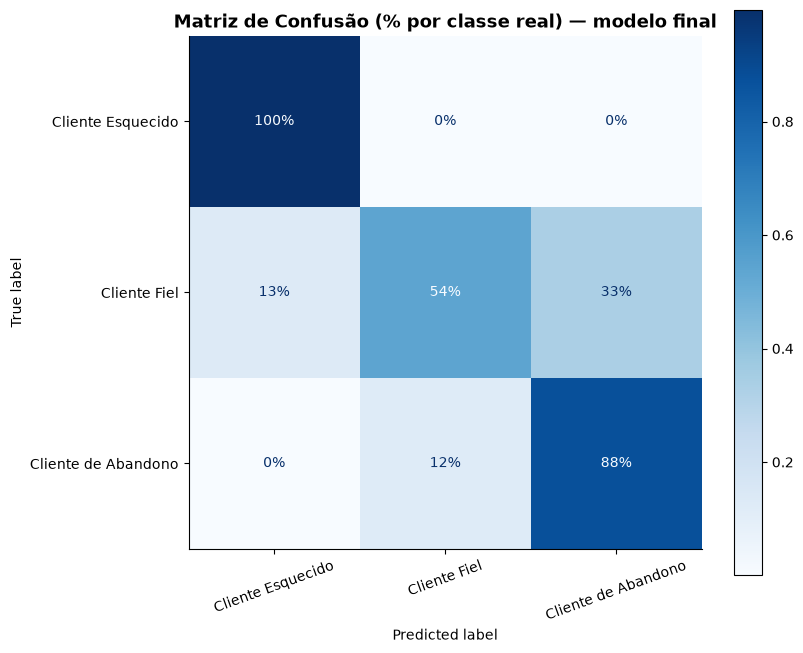

In [27]:
final_pipe = pipe_ajustado          # treinado no conjunto de treino com os melhores hiperparâmetros
y_pred = final_pipe.predict(X_te)
classes_modelo = list(final_pipe.classes_)

print("=" * 66)
print(f"  MODELO FINAL — {nome_ajustado}")
print("=" * 66)
print(f"Hiperparâmetros: { {k.replace('clf__', ''): v for k, v in busca.best_params_.items()} }\n")
print(classification_report(y_te, y_pred, digits=3))

# Checagem de overfitting: treino × teste
f1_tr = f1_score(y_tr, final_pipe.predict(X_tr), average='macro')
f1_te = f1_score(y_te, y_pred, average='macro')
print(f"F1 macro — treino: {f1_tr:.4f} | teste: {f1_te:.4f} | diferença: {f1_tr - f1_te:+.4f}")

print("\nMatriz de confusão (contagens; linhas = real, colunas = previsto):")
print(pd.DataFrame(confusion_matrix(y_te, y_pred, labels=classes_modelo), index=classes_modelo, columns=classes_modelo))

fig, ax = plt.subplots(figsize=(8.5, 7))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, labels=classes_modelo, normalize='true',
                                        cmap='Blues', values_format='.0%', ax=ax)
ax.set_title("Matriz de Confusão (% por classe real) — modelo final", fontsize=13, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "matriz_confusao.png", dpi=150, bbox_inches='tight')
plt.show()

### 9.7 Análise de sensibilidade — o que acontece sem as features "ancoradas" na data de referência?

Aqui está a pergunta mais importante para a credibilidade da solução: **quanto do desempenho vem de saber a idade do veículo?** Treinamos o mesmo modelo (mesmos hiperparâmetros) com conjuntos de features cada vez mais restritos:

| Cenário | Features | Leitura |
|---|---|---|
| **A. Base ativa** (modelo final) | modelo, ano, prazos, `tempo_garantia_ate_hoje` | Cenário de scoring da base ativa |
| **B.** Sem `tempo_garantia_ate_hoje` | modelo, ano, prazos | O `ano_modelo` continua carregando a idade |
| **C.** Sem ano nem tempo de garantia | modelo, prazos | Aproxima o **"Dia Zero"**: nada de idade explícita |
| **D.** Só o modelo do veículo | `ModelName` | Quanto a "linha" do veículo explica sozinha |

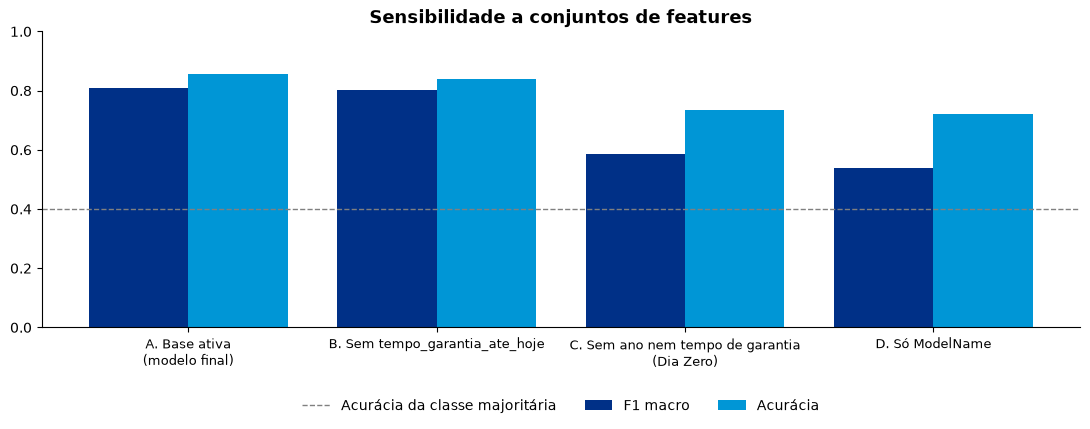

,accuracy,f1_macro,f1_weighted,roc_auc_ovr
modelo,,,,
A. Base ativa (modelo final),0.8558,0.8091,0.8488,0.9265
B. Sem tempo_garantia_ate_hoje,0.8403,0.8012,0.8383,0.9211
C. Sem ano nem tempo de garantia (Dia Zero),0.7356,0.5849,0.6737,0.8186
D. Só ModelName,0.7199,0.5384,0.6413,0.7770


In [28]:
cenarios = {
    'A. Base ativa (modelo final)':               FS_BASE_ATIVA,
    'B. Sem tempo_garantia_ate_hoje':             ['ano_modelo', 'dias_venda_entrega', 'dias_entrega_garantia', 'ModelName'],
    'C. Sem ano nem tempo de garantia (Dia Zero)': FS_DIA_ZERO,
    'D. Só ModelName':                            ['ModelName'],
}
clf_final = clone(final_pipe.named_steps['clf'])

linhas = []
for nome, fs in cenarios.items():
    pipe = montar_pipeline(fs, clone(clf_final)).fit(df_tr[fs], y_tr)
    linhas.append(avaliar(pipe, df_te[fs], y_te, nome))
ablacao = pd.DataFrame(linhas).set_index('modelo')

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(ablacao))
ax.bar(x - 0.2, ablacao['f1_macro'], width=0.4, color='#003087', label='F1 macro')
ax.bar(x + 0.2, ablacao['accuracy'], width=0.4, color='#0096D6', label='Acurácia')
ax.axhline(resultados_teste[0]['accuracy'], color='gray', ls='--', lw=1, label='Acurácia da classe majoritária')
ax.set_xticks(x); ax.set_xticklabels([n.replace(' (', '\n(') for n in ablacao.index], fontsize=9)
ax.set_ylim(0, 1); ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
ax.set_title("Sensibilidade a conjuntos de features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "sensibilidade_features.png", dpi=150, bbox_inches='tight')
plt.show()
ablacao.round(4)

### 9.8 O modelo agrega valor dentro de cada geração de veículos?

Como veículos novos são quase todos "Esquecidos" e veículos antigos quase todos "Abandono" (a idade quase define o rótulo), a acurácia global pode enganar. A comparação justa é **dentro de cada coorte de `ano_modelo`**: o modelo é melhor do que simplesmente prever a classe mais comum daquela coorte (regra aprendida no treino)?

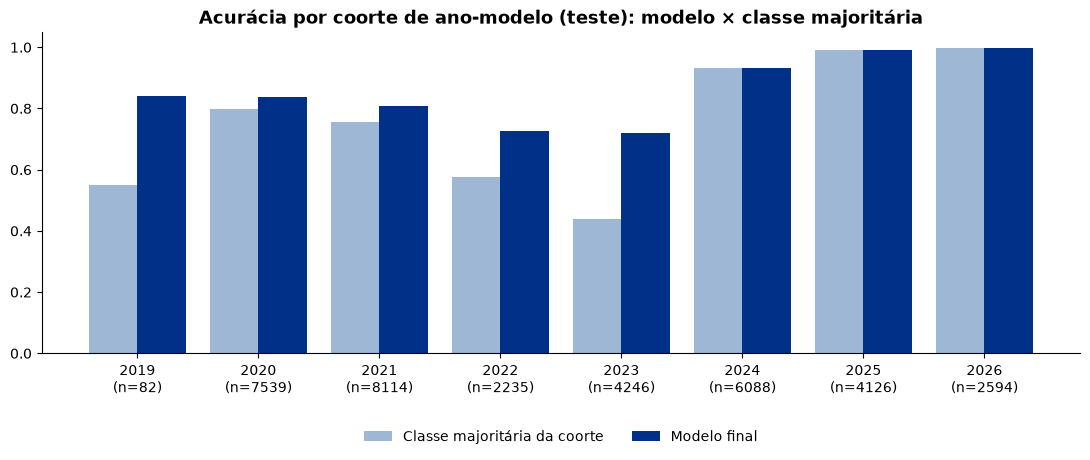

,n_teste,% Esquecido,% Fiel,% Abandono,acc_classe_majoritaria_da_coorte,acc_modelo,ganho_pp
ano_modelo,,,,,,,
2018,4,0.000,50.000,50.000,0.500,0.750,25.000
2019,82,0.000,45.122,54.878,0.549,0.841,29.268
2020,7539,0.000,20.069,79.931,0.799,0.837,3.727
2021,8114,0.000,24.538,75.462,0.755,0.809,5.484
2022,2235,3.758,57.584,38.658,0.576,0.725,14.944
2023,4246,37.400,43.994,18.606,0.440,0.721,28.121
2024,6088,93.150,6.833,0.016,0.932,0.932,0.000
2025,4126,99.079,0.921,0.000,0.991,0.991,0.000
2026,2594,99.807,0.193,0.000,0.998,0.998,0.000


In [29]:
pred_te = pd.Series(y_pred, index=df_te.index)
maj_treino = df_tr.groupby('ano_modelo')['perfil'].agg(lambda s: s.value_counts().idxmax())

linhas = []
for ano, g in df_te.groupby('ano_modelo'):
    if ano not in maj_treino.index:
        continue
    linhas.append({
        'ano_modelo': int(ano), 'n_teste': len(g),
        '% Esquecido': (g['perfil'] == 'Cliente Esquecido').mean() * 100,
        '% Fiel': (g['perfil'] == 'Cliente Fiel').mean() * 100,
        '% Abandono': (g['perfil'] == 'Cliente de Abandono').mean() * 100,
        'acc_classe_majoritaria_da_coorte': (g['perfil'] == maj_treino[ano]).mean(),
        'acc_modelo': (pred_te[g.index] == g['perfil']).mean(),
    })
coortes = pd.DataFrame(linhas).set_index('ano_modelo')
coortes['ganho_pp'] = (coortes['acc_modelo'] - coortes['acc_classe_majoritaria_da_coorte']) * 100

plot = coortes[coortes['n_teste'] >= 50]
fig, ax = plt.subplots(figsize=(11, 4.8))
x = np.arange(len(plot))
ax.bar(x - 0.2, plot['acc_classe_majoritaria_da_coorte'], width=0.4, color='#9DB7D5', label='Classe majoritária da coorte')
ax.bar(x + 0.2, plot['acc_modelo'], width=0.4, color='#003087', label='Modelo final')
ax.set_xticks(x); ax.set_xticklabels([f"{a}\n(n={n})" for a, n in zip(plot.index, plot['n_teste'])])
ax.set_ylim(0, 1.05); ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
ax.set_title("Acurácia por coorte de ano-modelo (teste): modelo × classe majoritária", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "coortes_ano_modelo.png", dpi=150, bbox_inches='tight')
plt.show()
coortes.round(3)

### 9.9 Explicabilidade — importância por permutação

A importância por impureza (Gini) do Random Forest é enviesada para variáveis contínuas e não mede o efeito no desempenho real. Usamos **importância por permutação**: embaralha-se uma feature por vez no conjunto de teste e mede-se a **queda no F1 macro** do modelo final.

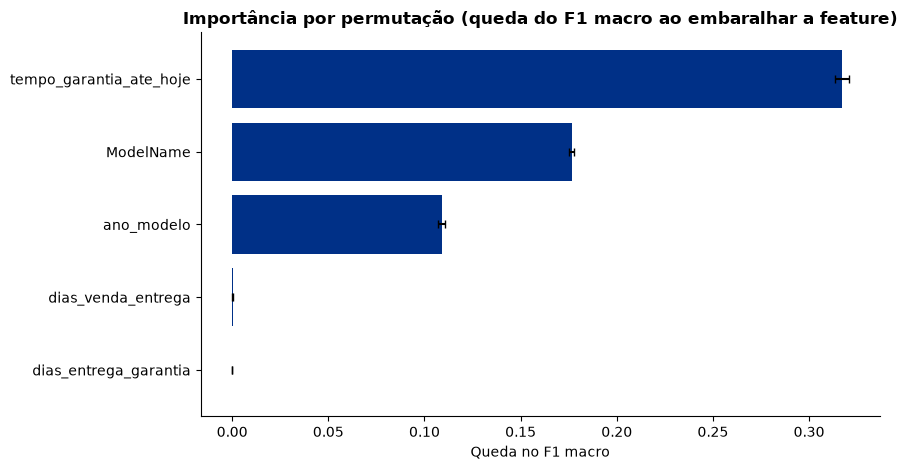

,queda_f1_macro,desvio
tempo_garantia_ate_hoje,0.3173,0.0036
ModelName,0.1765,0.0012
ano_modelo,0.1090,0.0018
dias_venda_entrega,0.0003,0.0003
dias_entrega_garantia,-0.0002,0.0001


In [30]:
amostra = df_te.sample(min(15_000, len(df_te)), random_state=RANDOM_STATE)
pi = permutation_importance(final_pipe, amostra[FS_BASE_ATIVA], amostra['perfil'],
                            scoring='f1_macro', n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.DataFrame({'queda_f1_macro': pi.importances_mean, 'desvio': pi.importances_std},
                   index=FS_BASE_ATIVA).sort_values('queda_f1_macro')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(imp.index, imp['queda_f1_macro'], xerr=imp['desvio'], color='#003087', capsize=3)
ax.set_title("Importância por permutação (queda do F1 macro ao embaralhar a feature)", fontsize=12, fontweight='bold')
ax.set_xlabel("Queda no F1 macro")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
imp.sort_values('queda_f1_macro', ascending=False).round(4)

## 10. Conclusão

In [31]:
# Resumo executivo (todos os números são calculados, nenhum digitado)
m_final = tabela_teste.loc[nome_ajustado]
m_maj   = tabela_teste.loc['Baseline 1 — classe majoritária']
m_b2    = tabela_teste.loc['Baseline 2 — só ano_modelo (árvore rasa)']
m_b3    = tabela_teste.loc['Baseline 3 — só tempo_garantia_ate_hoje (árvore rasa)']
rep = classification_report(y_te, y_pred, output_dict=True)

print("=" * 66)
print("        RESUMO EXECUTIVO — FORD VISION IA/ML (Sprint 3)")
print("=" * 66)
print("\nSEGMENTAÇÃO (Base 1 — histórico de visitas):")
for p in ['Cliente Fiel', 'Cliente Esquecido', 'Cliente de Abandono']:
    n = (base1['perfil'] == p).sum()
    print(f"  {p:22s}: {n:>7,} veículos ({n/len(base1)*100:4.1f}%)")
print(f"  K = {K_FINAL} | Silhouette {sil:.3f} | Davies-Bouldin {db:.3f}")

print(f"\nCLASSIFICAÇÃO (scoring da base ativa) — {nome_ajustado}:")
print(f"  Acurácia            : {m_final['accuracy']:.3f}   (classe majoritária {m_maj['accuracy']:.3f}; só ano_modelo {m_b2['accuracy']:.3f}; só tempo de garantia {m_b3['accuracy']:.3f})")
print(f"  F1 macro            : {m_final['f1_macro']:.3f}   (classe majoritária {m_maj['f1_macro']:.3f}; só ano_modelo {m_b2['f1_macro']:.3f}; só tempo de garantia {m_b3['f1_macro']:.3f})")
print(f"  ROC-AUC (OvR macro) : {m_final['roc_auc_ovr']:.3f}")
for p in classes_modelo:
    print(f"  {p:22s}: precisão {rep[p]['precision']:.2f} | recall {rep[p]['recall']:.2f} | F1 {rep[p]['f1-score']:.2f}")
print(f"\nSensibilidade (F1 macro): base ativa {ablacao.iloc[0]['f1_macro']:.3f} → sem tempo de garantia {ablacao.iloc[1]['f1_macro']:.3f} → "
      f"'Dia Zero' {ablacao.iloc[2]['f1_macro']:.3f}")
print(f"Feature mais importante (permutação): {imp['queda_f1_macro'].idxmax()}")

        RESUMO EXECUTIVO — FORD VISION IA/ML (Sprint 3)

SEGMENTAÇÃO (Base 1 — histórico de visitas):
  Cliente Fiel          :  35,787 veículos (20.4%)
  Cliente Esquecido     :  70,097 veículos (40.0%)
  Cliente de Abandono   :  69,253 veículos (39.5%)
  K = 3 | Silhouette 0.453 | Davies-Bouldin 1.011

CLASSIFICAÇÃO (scoring da base ativa) — Gradient Boosting (Hist) — ajustado:
  Acurácia            : 0.856   (classe majoritária 0.400; só ano_modelo 0.791; só tempo de garantia 0.818)
  F1 macro            : 0.809   (classe majoritária 0.191; só ano_modelo 0.736; só tempo de garantia 0.745)
  ROC-AUC (OvR macro) : 0.926
  Cliente Esquecido     : precisão 0.94 | recall 1.00 | F1 0.97
  Cliente Fiel          : precisão 0.69 | recall 0.54 | F1 0.61
  Cliente de Abandono   : precisão 0.84 | recall 0.88 | F1 0.86

Sensibilidade (F1 macro): base ativa 0.809 → sem tempo de garantia 0.801 → 'Dia Zero' 0.585
Feature mais importante (permutação): tempo_garantia_ate_hoje


### 10.1 Modelo selecionado

**Gradient Boosting (`HistGradientBoostingClassifier`) com hiperparâmetros ajustados**, treinado sobre 5 features cadastrais (modelo, ano-modelo, prazos de venda/entrega/garantia e tempo de garantia decorrido), com pré-processamento dentro do `Pipeline`. Hiperparâmetros escolhidos pela busca da seção 9.4: `learning_rate=0,05`, `max_leaf_nodes=15`, `min_samples_leaf=20`, `l2_regularization=0,1`, `max_iter=100`.

### 10.2 Justificativa da escolha

- **Critério pré-definido:** maior F1 macro na validação cruzada (0,8094), sem uso do conjunto de teste.
- **Empate técnico entre algoritmos.** As cinco famílias ficaram entre 0,806 e 0,809 de F1 macro — diferenças de ~0,003, da ordem do desvio entre folds (±0,001–0,002) — e o ajuste de hiperparâmetros rendeu apenas +0,0001. **O teto de desempenho é determinado pelas features, não pelo algoritmo.** Isso é um resultado, não uma falha: indica que trocar de modelo não melhoraria a solução; só novos dados melhorariam.
- **Critérios de desempate operacionais:** melhor ROC-AUC (0,926, empatado com o topo), treino em ~2 s por fold, artefato de ~200 KB, tratamento nativo de não linearidades e nulos. Como alternativa **totalmente explicável**, a Árvore de Decisão (profundidade 8) perde apenas 0,0007 de F1 macro e pode ser usada se a Ford priorizar regras auditáveis.
- **Sem overfitting relevante:** F1 macro de treino 0,810 × teste 0,809.

### 10.3 Principais resultados (conjunto de teste, 35.028 veículos)

| Modelo | Acurácia | F1 macro | ROC-AUC |
|---|---|---|---|
| Classe majoritária | 0,400 | 0,191 | 0,500 |
| Só `ano_modelo` (árvore rasa) | 0,791 | 0,736 | 0,886 |
| Só `tempo_garantia_ate_hoje` (árvore rasa) | 0,818 | 0,745 | 0,896 |
| **Modelo final** | **0,856** | **0,809** | **0,926** |

- O modelo supera a melhor referência simples em **+3,8 p.p. de acurácia e +6,4 p.p. de F1 macro**: o ganho é real, porém modesto — a maior parte do sinal já está na idade/tempo de garantia do veículo.
- **Por perfil:** Esquecido F1 0,97 (recall ≈ 1,00) · Abandono F1 0,86 · **Fiel F1 0,61** (recall 0,54). A classe Fiel é a difícil: dos 7.157 Fiéis no teste, 2.377 foram classificados como Abandono. Distinguir quem é fiel de quem abandonou, entre veículos da mesma idade, exige **dados comportamentais** que o cadastro não tem.
- **Importância por permutação:** `tempo_garantia_ate_hoje` (queda de 0,32 no F1 macro) > `ModelName` (0,18) > `ano_modelo` (0,13); os prazos de venda/entrega/garantia praticamente não contribuem.

### 10.4 O que os resultados significam (leitura honesta)

1. **O "Cliente Esquecido" é, na prática, o veículo novo em garantia.** Nas coortes 2024, 2025 e 2026, 93%, 99% e 99,8% dos veículos são "Esquecidos"; nelas o modelo apenas acompanha a classe majoritária (ganho de 0 p.p., seção 9.8).
2. **Onde o modelo agrega valor é nas coortes mistas**, de 2020 a 2023: +3,7, +5,5, +15,0 e +28,1 p.p. de acurácia sobre a classe majoritária da coorte.
3. **A solução não é uma previsão no "Dia Zero".** Sem idade nem tempo de garantia (cenário C, seção 9.7), o F1 macro cai de 0,809 para 0,585 (acurácia 0,736) — acima do acaso, mas muito abaixo do scoring da base ativa. Por isso o projeto foi enquadrado como **scoring da base ativa**, e não como previsão no momento da venda.

### 10.5 Limitações

- **Pseudo-rótulos.** O alvo vem de uma clusterização que usa `garantia_ativa` e `idade_veiculo_anos`, funções das mesmas datas usadas nas features: existe circularidade parcial (quantificada nos baselines e na ablação).
- **Viés de sobrevivência.** A base contém apenas veículos com **pelo menos uma visita** à rede oficial. O VIN Share exige o denominador completo (todos os veículos vendidos, inclusive os que **nunca** voltaram) — a evasão total não está nos dados.
- **Censura temporal.** Veículos novos têm poucas visitas *por definição*, não por desinteresse.
- **Regras fixas:** garantia de 3 anos, janela de dados até 04/05/2026 e pesos do score de risco (0 / 0,5 / 1,0) são **premissas** a validar com a Ford.
- **Sem variáveis de contexto:** região, concessionária, tipo de serviço, preço, NPS, telemetria.

### 10.6 Trabalhos futuros

1. **Cruzar com a base completa de vendas (todos os VINs)** para medir evasão real e reformular o alvo como "retorna à rede nos próximos N meses" (classificação) ou *tempo até o próximo serviço* (análise de sobrevivência).
2. **Enriquecer as features:** dados de veículos conectados, histórico de garantia estendida/recalls, região e concessionária, satisfação (NPS).
3. **Evoluir a segmentação para K=4** (Fiel intensivo × em declínio), com ações específicas.
4. **Calibrar probabilidades e pesos de risco** com custo-benefício das campanhas, validando com **teste A/B** de ações de retenção.
5. **MLOps:** retreino periódico, monitoramento de *drift* (ex.: distribuição de `tempo_garantia_ate_hoje`, que cresce com o tempo) e de desempenho, versionamento do modelo.

## 11. Deploy e Integração com a Aplicação Ford Vision

### 11.1 Arquitetura proposta

```
 ┌────────────────┐    ┌──────────────────────┐    ┌───────────────────────────┐
 │ App mobile /   │───▶│ API de negócio       │───▶│ Serviço de ML (FastAPI)   │
 │ painel da      │    │ (JWT, perfis, REST)  │    │ /predict  /predict/batch  │
 │ concessionária │◀───│ — matéria de Arq.    │◀───│ pipeline .joblib          │
 └────────────────┘    └──────────────────────┘    └───────────────────────────┘
                                 ▲                              ▲
                                 │ leads por concessionária     │ retreino periódico (notebook)
                        ┌────────┴─────────┐          ┌─────────┴──────────┐
                        │ Base de vendas / │          │ Monitoramento:     │
                        │ CRM da Ford      │          │ drift + desempenho │
                        └──────────────────┘          └────────────────────┘
```

- O modelo é servido como **microsserviço** (`api/main.py`, FastAPI), consumido pela API de negócio da solução — que já concentra autenticação JWT e perfis de acesso. O serviço de ML fica em rede interna; opcionalmente exige `X-API-Key` (variável de ambiente `FORD_VISION_API_KEY`).
- **Dois modos de uso:** *tempo real* (`POST /predict`, ex.: tela do veículo no app) e *lote* (`POST /predict/batch`, até 1.000 veículos, ex.: geração noturna de leads por concessionária).
- A engenharia de features vive em **`src/features.py`**, usada tanto no treino quanto no serviço, para evitar divergência entre as duas pontas (validada abaixo).

### 11.2 Artefatos do modelo

In [32]:
# Modelo de produção: mesmos hiperparâmetros, retreinado em 100% da base
X_all, y_all = base2[FS_BASE_ATIVA], base2['perfil']
modelo_producao = clone(final_pipe).fit(X_all, y_all)

ARTEFATO = MODEL_DIR / 'perfil_retencao_pipeline.joblib'
joblib.dump(modelo_producao, ARTEFATO, compress=3)

metadata = {
    'modelo': nome_ajustado,
    'hiperparametros': {k.replace('clf__', ''): (list(v) if isinstance(v, tuple) else v) for k, v in busca.best_params_.items()},
    'features': FS_BASE_ATIVA,
    'classes': list(modelo_producao.classes_),
    'data_referencia_treino': str(DATA_REF.date()),
    'n_registros_treino': int(len(base2)),
    'sklearn_version': sklearn.__version__,
    'metricas_teste': {k: round(float(v), 4) for k, v in m_final.items()},
    'metricas_baselines_teste': {
        'classe_majoritaria': {k: round(float(v), 4) for k, v in m_maj.items()},
        'so_ano_modelo':      {k: round(float(v), 4) for k, v in m_b2.items()},
    },
    'observacoes': ('Scoring da base ativa. Rótulos derivados de clusterização (pseudo-rótulos). '
                    'Não representa previsão no Dia Zero da venda.'),
}
with open(MODEL_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Modelo salvo: {ARTEFATO.relative_to(ROOT)}  ({ARTEFATO.stat().st_size/1024:.0f} KB)")
print(f"Metadados   : {(MODEL_DIR / 'metadata.json').relative_to(ROOT)}")

Modelo salvo: models\perfil_retencao_pipeline.joblib  (195 KB)
Metadados   : models\metadata.json


### 11.3 Teste de paridade treino × serviço

Garante que `src/features.py` (usado pela API) produz **exatamente** as features usadas no treino.

In [33]:
from src.features import montar_features, PERFIL_INFO, PESO_RISCO

entrada = pd.DataFrame({
    'modelo':               base2['ModelName'],
    'ano_modelo':           base2['ModelYear'],
    'data_venda':           base2['SalesDate'],
    'data_entrega':         base2['DeliveryDate'],
    'data_inicio_garantia': base2['WarrantyStartDate'],
})
feats_servico = montar_features(entrada, DATA_REF)
pd.testing.assert_frame_equal(feats_servico.reset_index(drop=True),
                              base2[FS_BASE_ATIVA].reset_index(drop=True),
                              check_dtype=False, check_exact=False)
print(f"✅ Paridade OK em {len(base2):,} veículos: features do serviço == features do treino")

✅ Paridade OK em 175,137 veículos: features do serviço == features do treino


### 11.4 Exemplo de inferência (o mesmo caminho que a API executa)

In [34]:
exemplo = pd.DataFrame([{
    'modelo': 'Ranger', 'ano_modelo': 2022,
    'data_venda': '2022-03-10', 'data_entrega': '2022-03-25', 'data_inicio_garantia': '2022-03-25',
}])
X_ex = montar_features(exemplo, DATA_REF)
proba = modelo_producao.predict_proba(X_ex)[0]
probas = {c: float(round(p, 3)) for c, p in zip(modelo_producao.classes_, proba)}
perfil_ex = modelo_producao.classes_[proba.argmax()]
score = sum(probas[c] * PESO_RISCO[c] for c in probas)

print("Features calculadas:\n", X_ex.T.to_string(header=False))
print(f"\nProbabilidades: {probas}")
print(f"Perfil previsto: {perfil_ex} | risco: {PERFIL_INFO[perfil_ex]['nivel_risco']} | score de risco: {score:.2f}")
print(f"Ação sugerida: {PERFIL_INFO[perfil_ex]['acao_sugerida']}")

Features calculadas:
 ano_modelo                 2022
dias_venda_entrega           15
dias_entrega_garantia         0
tempo_garantia_ate_hoje    1501
ModelName                RANGER

Probabilidades: {'Cliente Esquecido': 0.002, 'Cliente Fiel': 0.781, 'Cliente de Abandono': 0.218}
Perfil previsto: Cliente Fiel | risco: Baixo | score de risco: 0.22
Ação sugerida: Programa de fidelidade, agendamento antecipado automático e ofertas exclusivas.


### 11.5 Geração de leads por concessionária (uso em lote)

Para pontuar toda a base **sem viés de reavaliar dados de treino**, usamos predições *out-of-fold* (`cross_val_predict`, 3 folds): cada veículo é pontuado por um modelo que **não o viu no treino**. O **score de risco esperado** combina as probabilidades com pesos por perfil (Fiel = 0, Esquecido = 0,5, Abandono = 1,0 — **premissas de negócio a calibrar com a Ford**).

In [35]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
proba_oof = cross_val_predict(clone(final_pipe), X_all, y_all, cv=cv3, method='predict_proba', n_jobs=1)
classes_oof = list(modelo_producao.classes_)

leads = base2[['VIN_Hash', 'dealer_ultima_visita', 'ModelName', 'ano_modelo']].copy()
for i, c in enumerate(classes_oof):
    leads[f'p_{c}'] = proba_oof[:, i]
leads['perfil_previsto'] = np.array(classes_oof)[proba_oof.argmax(axis=1)]
leads['score_risco'] = sum(leads[f'p_{c}'] * PESO_RISCO[c] for c in classes_oof)
leads['acao_sugerida'] = leads['perfil_previsto'].map(lambda p: PERFIL_INFO[p]['acao_sugerida'])

resumo_dealer = (leads.groupby('dealer_ultima_visita')
                 .agg(veiculos=('VIN_Hash', 'count'),
                      abandono_previsto=('perfil_previsto', lambda s: (s == 'Cliente de Abandono').sum()),
                      esquecido_previsto=('perfil_previsto', lambda s: (s == 'Cliente Esquecido').sum()),
                      risco_medio=('score_risco', 'mean')))
resumo_dealer['% abandono previsto'] = (resumo_dealer['abandono_previsto'] / resumo_dealer['veiculos'] * 100).round(1)

print(f"Concessionárias: {len(resumo_dealer)} | veículos pontuados: {len(leads):,}")
print("\nTop 10 concessionárias por volume de veículos com perfil de Abandono previsto:")
resumo_dealer.sort_values('abandono_previsto', ascending=False).head(10).round(3)

Concessionárias: 395 | veículos pontuados: 175,137

Top 10 concessionárias por volume de veículos com perfil de Abandono previsto:


,veiculos,abandono_previsto,esquecido_previsto,risco_medio,% abandono previsto
dealer_ultima_visita,,,,,
6163,3404,2093,874,0.676,61.5
6137,3539,1992,1136,0.653,56.3
6177,2719,1882,543,0.710,69.2
1247,3404,1815,1194,0.641,53.3
3028,2124,1476,441,0.711,69.5
6173,2436,1445,757,0.673,59.3
5010,2511,1329,805,0.637,52.9
4146,3154,1156,1627,0.592,36.7
4001,3216,1121,1406,0.559,34.9


### 11.6 Como executar a API

```bash
pip install -r requirements.txt
uvicorn api.main:app --reload            # a partir da raiz do repositório
# docs interativas (Swagger): http://127.0.0.1:8000/docs
```

```bash
curl -X POST http://127.0.0.1:8000/predict -H "Content-Type: application/json" -d '{
  "modelo": "RANGER", "ano_modelo": 2022,
  "data_venda": "2022-03-10", "data_entrega": "2022-03-25", "data_inicio_garantia": "2022-03-25"
}'
```

Testes automatizados da API: `pytest tests/`.

## 12. Exportação dos Resultados

In [36]:
# Exporta bases e leads (pasta data/ é ignorada pelo Git: contém dados da Ford)
base1.drop(columns=['pca1', 'pca2'], errors='ignore').to_csv(DATA_PROC / "base1_segmentada.csv", index=False)
base2.to_csv(DATA_PROC / "base2_classificada.csv", index=False)
leads.to_csv(DATA_PROC / "leads_scoring_base_ativa.csv", index=False)

print("✅ Arquivos gerados:")
for p in [DATA_PROC / "base1_segmentada.csv", DATA_PROC / "base2_classificada.csv",
          DATA_PROC / "leads_scoring_base_ativa.csv", ARTEFATO, MODEL_DIR / "metadata.json"]:
    print(f"  • {p.relative_to(ROOT)}")

✅ Arquivos gerados:
  • data\processed\base1_segmentada.csv
  • data\processed\base2_classificada.csv
  • data\processed\leads_scoring_base_ativa.csv
  • models\perfil_retencao_pipeline.joblib
  • models\metadata.json
